# OPF


In [17]:
import sys
import os
import torch
from torch.autograd import Function
torch.set_default_dtype(torch.float64)
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import scipy
from scipy.sparse import csr_matrix
sys.path.insert(1, os.path.join(sys.path[0], os.pardir, os.pardir))
import hashlib
from copy import deepcopy
from pypower.api import opf, makeYbus, makeB
from pypower import idx_bus, idx_gen, ppoption
import time
import argparse
import pyomo.environ as pyo
import numpy as np
import torch
import time
import torch.nn as nn
import matplotlib.pyplot as plt
import scipy.io as spio
from pypower.api import case118
# from pypower.api import case300
current_dir = os.getcwd()
dir = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
sys.path.append(dir) # Add the parent directory to Python's search path
results_dir = os.path.join(current_dir, "examples/results")
from Opt_Layer.pyomolayer import PyomoOptLayer

In [18]:
data_dir = "data_OPF"
save_dir = os.path.join("results")
case_dir = os.path.join(current_dir, data_dir)
def str_to_bool(value):
    if isinstance(value, bool):
        return value
    if value.lower() in {'false', 'f', '0', 'no', 'n'}:
        return False
    elif value.lower() in {'true', 't', '1', 'yes', 'y'}:
        return True
    raise ValueError('{value} is not a valid boolean value')

def my_hash(string):
    return hashlib.sha1(bytes(string, 'utf-8')).hexdigest()

In [19]:
parser = argparse.ArgumentParser(description='DC3')
parser.add_argument('--probType', type=str, default='acopf57', help='problem type')
parser.add_argument('--epochs', type=int, default=100,
    help='number of neural network epochs')
parser.add_argument('--batchSize', type=int, default=8,
    help='training batch size')
parser.add_argument('--lr', type=float, default=0.0005,
    help='neural network learning rate')
parser.add_argument('--hiddenSize', type=int, default=256,
    help='hidden layer size for neural network')
parser.add_argument('--saveAllStats', type=str_to_bool, default=False,
    help='whether to save all stats, or just those from latest epoch')
parser.add_argument('--resultsSaveFreq', type=int, default=10,
    help='how frequently (in terms of number of epochs) to save stats to file')

args = parser.parse_args([])
args = vars(args) # change to dictionary
print(args)

{'probType': 'acopf57', 'epochs': 100, 'batchSize': 8, 'lr': 0.0005, 'hiddenSize': 256, 'saveAllStats': False, 'resultsSaveFreq': 10}


In [20]:
class ACOPFProblem:
    def __init__(self, data, ppc, num, valid_frac=0.1, test_frac=0.2):
        self.nbus = ppc['bus'].shape[0]

        self.ppc = ppc

        self.genbase = ppc['gen'][:, idx_gen.MBASE]
        self.baseMVA = ppc['baseMVA'] * 1.0
        # self.connect_matrix = ppc['connect_matrix']

        self.slack = np.where(ppc['bus'][:, idx_bus.BUS_TYPE] == 3)[0]
        self.pv = np.where(ppc['bus'][:, idx_bus.BUS_TYPE] == 2)[0]
        self.spv = np.concatenate([self.slack, self.pv])
        self.spv.sort()
        self.pq = np.setdiff1d(range(self.nbus), self.spv)
        self.nonslack_idxes = np.sort(np.concatenate([self.pq, self.pv]))
        self.allbus_idxes = np.arange(self.nbus)

        # indices within gens
        self.slack_ = np.array([np.where(x == self.spv)[0][0] for x in self.slack])
        self.pv_ = np.array([np.where(x == self.spv)[0][0] for x in self.pv])
        self.pv_nonslack_idxes = np.array([np.where(x == self.nonslack_idxes)[0][0] for x in self.pv])

        self.ng = ppc['gen'].shape[0]
        self.allgen_idxes = np.arange(self.ng)
        self.nslack = len(self.slack)
        self.npv = len(self.pv)
        self.nbr = ppc['branch'].shape[0]

        self.quad_costs = torch.tensor(ppc['gencost'][:,4], dtype=torch.get_default_dtype())
        self.lin_costs  = torch.tensor(ppc['gencost'][:,5], dtype=torch.get_default_dtype())
        self.const_cost = ppc['gencost'][:,6].sum()

        self.pmax = torch.tensor(ppc['gen'][:,idx_gen.PMAX] / self.genbase, dtype=torch.get_default_dtype())
        self.pmin = torch.tensor(ppc['gen'][:,idx_gen.PMIN] / self.genbase, dtype=torch.get_default_dtype())
        self.qmax = torch.tensor(ppc['gen'][:,idx_gen.QMAX] / self.genbase, dtype=torch.get_default_dtype())
        self.qmin = torch.tensor(ppc['gen'][:,idx_gen.QMIN] / self.genbase, dtype=torch.get_default_dtype())
        self.vmax = torch.tensor(ppc['bus'][:,idx_bus.VMAX], dtype=torch.get_default_dtype())
        self.vmin = torch.tensor(ppc['bus'][:,idx_bus.VMIN], dtype=torch.get_default_dtype())
        self.slackva = torch.tensor([np.deg2rad(ppc['bus'][self.slack, idx_bus.VA])], dtype=torch.get_default_dtype()).squeeze(-1)
        self.bfmax = torch.tensor((ppc['branch'][:, 5] / self.baseMVA)**2, dtype=torch.get_default_dtype())

        ppc2 = deepcopy(ppc)
        ppc2['bus'][:, 0] -= 1
        ppc2['branch'][:, [0, 1]] -= 1
        Ybus, Yf, _ = makeYbus(self.baseMVA, ppc2['bus'], ppc2['branch'])
        Ybus = Ybus.todense()
        Yfbus = Yf.todense()
        self.Ybusr = torch.tensor(np.real(Ybus), dtype=torch.get_default_dtype())
        self.Ybusi = torch.tensor(np.imag(Ybus), dtype=torch.get_default_dtype())
        self.Yfbusr = torch.tensor(np.real(Yfbus), dtype=torch.get_default_dtype())
        self.Yfbusi = torch.tensor(np.imag(Yfbus), dtype=torch.get_default_dtype())
        self.line_susceptance = ppc2['branch'][:,4]

        Bp, Bpp = makeB(self.baseMVA, ppc2['bus'], ppc2['branch'], 2)
        Bp = Bp.todense()
        Bpp = Bpp.todense()
        Bp_reduced = Bp[np.concatenate([self.pv, self.pq]),:][:,np.concatenate([self.pv, self.pq])]
        Bpp_reduced = Bpp[np.concatenate([self.pq]),:][:,np.concatenate([self.pq])]
        self.Bp = torch.inverse(torch.tensor(Bp_reduced, dtype=torch.get_default_dtype()))
        self.Bpp = torch.inverse(torch.tensor(Bpp_reduced, dtype=torch.get_default_dtype()))

        Bp_reduced1 = Bp[self.nonslack_idxes, :][:, self.nonslack_idxes]
        Bpp_reduced1 = Bpp[self.nonslack_idxes, :][:, self.nonslack_idxes]
        self.Bp1 = torch.inverse(torch.tensor(Bp_reduced1, dtype=torch.get_default_dtype()))
        self.Bpp1 = torch.inverse(torch.tensor(Bpp_reduced1, dtype=torch.get_default_dtype()))

        self.F_BUS = ppc2['branch'][:, 0].astype(int)
        self.T_BUS = ppc2['branch'][:, 1].astype(int)

        ppc3 = deepcopy(ppc2)
        ppc3['branch'][:, 4] = 0
        _, Yf_nosus, _ = makeYbus(self.baseMVA, ppc3['bus'], ppc3['branch'])
        Yfbus_nosus = Yf_nosus.todense()
        self.Yfbusr_nosus = torch.tensor(np.real(Yfbus_nosus), dtype=torch.get_default_dtype())
        self.Yfbusi_nosus = torch.tensor(np.imag(Yfbus_nosus), dtype=torch.get_default_dtype())

        self.Cf = torch.tensor(np.transpose(csr_matrix((np.ones(self.nbr), (range(self.nbr), self.F_BUS)), (self.nbr, self.nbus)).todense()), dtype=torch.get_default_dtype())
        self.Ct = torch.tensor(np.transpose(csr_matrix((np.ones(self.nbr), (range(self.nbr), self.T_BUS)), (self.nbr, self.nbus)).todense()), dtype=torch.get_default_dtype())
        self.adj = self.Cf - self.Ct
        ## Define optimization problem input and output variables
        demand = data['Dem'].T / self.baseMVA
        gen =  data['Gen'].T / self.genbase
        voltage = data['Vol'].T
        # branch_flow = branch_flow / self.baseMVA / self.baseMVA

        X = np.concatenate([np.real(demand), np.imag(demand)], axis=1)[:num,:]
        Y = np.concatenate([np.real(gen), np.imag(gen), np.abs(voltage), np.angle(voltage)], axis=1)[:num,:]
        feas_mask =  ~np.isnan(Y).any(axis=1)

        self._X = torch.tensor(X[feas_mask], dtype=torch.get_default_dtype())
        self._Y = torch.tensor(Y[feas_mask], dtype=torch.get_default_dtype())
        self._xdim = X.shape[1]
        self._ydim = Y.shape[1]
        self._num = feas_mask.sum()

        self._neq = 2*self.nbus
        self._nineq = 4*self.ng + 2*self.nbus
        self._nknowns = self.nslack

        # indices of useful quantities in full solution
        self.pg_start_yidx = 0
        self.qg_start_yidx = self.ng
        self.vm_start_yidx = 2*self.ng
        self.va_start_yidx = 2*self.ng + self.nbus
        self.bf_start_yidx = 2*self.ng + 2*self.nbus
        ## Define train/valid/test split
        self._valid_frac = valid_frac
        self._test_frac = test_frac

        ## Define variables and indices for "partial completion" neural network

        # pg (non-slack) and |v|_g (including slack)
        self._partial_vars = np.concatenate([self.pg_start_yidx + self.pv_, self.vm_start_yidx + self.spv, self.va_start_yidx + self.slack])
        self._partial_vars_bf = np.concatenate([self.spv, self.nbus + self.slack])
        self._other_vars = np.setdiff1d(np.arange(self.ydim), self._partial_vars)
        self._partial_unknown_vars = np.concatenate([self.pg_start_yidx + self.pv_, self.vm_start_yidx + self.spv])

        # initial values for solver
        self.vm_init = ppc['bus'][:, idx_bus.VM]
        self.va_init = np.deg2rad(ppc['bus'][:, idx_bus.VA])
        self.pg_init = ppc['gen'][:, idx_gen.PG] / self.genbase
        self.qg_init = ppc['gen'][:, idx_gen.QG] / self.genbase

        # voltage angle at slack buses (known)
        self.slack_va = self.va_init[self.slack]

        # indices of useful quantities in partial solution
        self.pg_pv_zidx = np.arange(self.npv)
        self.vm_spv_zidx = np.arange(self.npv, 2*self.npv + self.nslack)

        # indices of useful quantities in partial solution for post processing
        self.pg_zidx = np.arange(self.npv)
        self.qg_zidx = np.arange(self.npv, self.npv+self.npv)

        # useful indices for equality constraints
        self.pflow_start_eqidx = 0
        self.qflow_start_eqidx = self.nbus


        ### For Pytorch
        self._device = None

    @property
    def X(self):
        return self._X

    @property
    def Y(self):
        return self._Y

    @property
    def partial_vars(self):
        return self._partial_vars

    @property
    def partial_vars_bf(self):
        return self._partial_vars_bf

    @property
    def other_vars(self):
        return self._other_vars

    @property
    def partial_unknown_vars(self):
        return self._partial_unknown_vars

    @property
    def xdim(self):
        return self._xdim

    @property
    def ydim(self):
        return self._ydim

    @property
    def num(self):
        return self._num

    @property
    def neq(self):
        return self._neq

    @property
    def nineq(self):
        return self._nineq

    @property
    def nknowns(self):
        return self._nknowns

    @property
    def valid_frac(self):
        return self._valid_frac

    @property
    def test_frac(self):
        return self._test_frac

    @property
    def train_frac(self):
        return 1 - self.valid_frac - self.test_frac

    @property
    def trainX(self):
        return self.X[:int(self.num * self.train_frac)]

    @property
    def validX(self):
        return self.X[int(self.num * self.train_frac):int(self.num * (self.train_frac + self.valid_frac))]

    @property
    def testX(self):
        return self.X[int(self.num * (self.train_frac + self.valid_frac)):]

    @property
    def trainY(self):
        return self.Y[:int(self.num*self.train_frac)]

    @property
    def validY(self):
        return self.Y[int(self.num*self.train_frac):int(self.num*(self.train_frac + self.valid_frac))]

    @property
    def testY(self):
        return self.Y[int(self.num*(self.train_frac + self.valid_frac)):]

    @property
    def device(self):
        return self._device

    def trainX_fake(self, X, num_fake):
        return X[:int(num_fake*self.train_frac)]

    def validX_fake(self, X, num_fake):
        return X[int(num_fake*self.train_frac):int(num_fake*(self.train_frac + self.valid_frac))]

    def testX_fake(self, X, num_fake):
        return X[int(num_fake*(self.train_frac + self.valid_frac)):]

    def trainY_fake(self, Y, num_fake):
        return Y[:int(num_fake*self.train_frac)]

    def validY_fake(self, Y, num_fake):
        return Y[int(num_fake*self.train_frac):int(num_fake*(self.train_frac + self.valid_frac))]

    def testY_fake(self, Y, num_fake):
        return Y[int(num_fake*(self.train_frac + self.valid_frac)):]


    def get_yvars(self, Y):
        pg = Y[:, :self.ng]
        qg = Y[:, self.ng:2*self.ng]
        vm = Y[:, 2*self.ng:2*self.ng+self.nbus]
        va = Y[:, 2*self.ng+self.nbus:2*self.ng+2*self.nbus]
        # bf = Y[:, 2*self.ng+2*self.nbus:]
        return pg, qg, vm, va

    def obj_fn(self, Y):
        pg, _, _, _  = self.get_yvars(Y)
        pg_mw = pg * torch.tensor(self.genbase).to(self.device)
        cost = (self.lin_costs * pg_mw).sum(axis=1) 
        return cost / (self.genbase.mean() ** 2)

    def gen_cost(self, pg):
        pg_mw = pg * torch.tensor(self.genbase).to(self.device)
        cost = (self.lin_costs * pg_mw).sum(axis=1) 
        return cost / (self.genbase.mean() ** 2)
    
    def eq_resid(self, X, Y):
        pg, qg, vm, va = self.get_yvars(Y)

        vr = vm*torch.cos(va)
        vi = vm*torch.sin(va)

        ## power balance equations
        tmp1 = vr@self.Ybusr - vi@self.Ybusi
        tmp2 = -vr@self.Ybusi - vi@self.Ybusr

        # real power
        pg_expand = torch.zeros(pg.shape[0], self.nbus, device=self.device)
        pg_expand[:, self.spv] = pg
        real_resid = (pg_expand - X[:, :self.nbus]) - (vr*tmp1 - vi*tmp2)

        # reactive power
        qg_expand = torch.zeros(qg.shape[0], self.nbus, device=self.device)
        qg_expand[:, self.spv] = qg
        react_resid = (qg_expand - X[:, self.nbus:]) - (vr*tmp2 + vi*tmp1)

        ## all residuals
        resids = torch.cat([
            real_resid,
            react_resid
        ], dim=1)

        return resids

    def eq_resid_bf(self, X, Y):
        _, _, vm, va = self.get_yvars(Y)

        vr = vm*torch.cos(va)
        vi = vm*torch.sin(va)

        vfr = vr@self.Cf # 8 *41
        vfi = vi@self.Cf # 8 *41

        ## power balance equations
        tmp1 = vr@torch.transpose(self.Yfbusr,0,1) - vi@torch.transpose(self.Yfbusi,0,1) # batch_size * nbr
        tmp2 = -vr@torch.transpose(self.Yfbusi,0,1) - vi@torch.transpose(self.Yfbusr,0,1)

        # real power flow
        pf = (vfr*tmp1 - vfi*tmp2)

        # reactive power flow
        qf = (vfr*tmp2 + vfi*tmp1)

        return pf, qf

    def ineq_resid(self, X, Y):
        pg, qg, vm, va = self.get_yvars(Y)
        resids = torch.cat([
            pg - self.pmax,
            self.pmin - pg,
            qg - self.qmax,
            self.qmin - qg,
            vm - self.vmax,
            self.vmin - vm,
        ], dim=1)
        return resids

    def ineq_dist(self, X, Y):
        resids = self.ineq_resid(X, Y)
        return torch.clamp(resids, 0)

    def ineq_resid_bf(self, X, Y, bf, bounded_branch):
        pg, qg, vm, va = self.get_yvars(Y)
        resids = torch.cat([
            pg - self.pmax,
            self.pmin - pg,
            qg - self.qmax,
            self.qmin - qg,
            vm - self.vmax,
            self.vmin - vm,
            bf[:, bounded_branch] - self.bfmax[bounded_branch]
        ], dim=1)
        return resids

    def ineq_dist_bf(self, X, Y, bf, bounded_branch):
        resids = self.ineq_resid_bf(X, Y, bf, bounded_branch)
        return torch.clamp(resids, 0)
    
    def ineq_resid_imp(self, X, Y):
        _, _, vm, _, _ = self.get_yvars(Y)
        vm_pq = vm[:, self.pq]
        resids = torch.cat([
            vm_pq - self.vmax[self.pq],
            self.vmin[self.pq] - vm_pq,
        ], dim=1)
        return resids

    def ineq_dist_imp(self, X, Y):
        resids = self.ineq_resid_imp(X, Y)
        return torch.clamp(resids, 0)

    def ineq_resid_Pg(self, X, Y):
        pg, qg, vm, va = self.get_yvars(Y)
        resids = torch.cat([
            pg - self.pmax,
            self.pmin - pg
        ], dim=1)
        return resids

    def ineq_dist_Pg(self, X, Y):
        resids = self.ineq_resid_Pg(X, Y)
        return torch.clamp(resids, 0)

    def eq_grad(self, X, Y):
        eq_jac = self.eq_jac(Y)
        eq_resid = self.eq_resid(X,Y)
        return 2*eq_jac.transpose(1,2).bmm(eq_resid.unsqueeze(-1)).squeeze(-1)

    def ineq_grad(self, X, Y):
        ineq_jac = self.ineq_jac(Y)
        ineq_dist = self.ineq_dist(X, Y)
        return 2*ineq_jac.transpose(1,2).bmm(ineq_dist.unsqueeze(-1)).squeeze(-1)

    def eq_jac_pfqf(self, Y):

        _, _, vm, va = self.get_yvars(Y)

        dreal_dvm = torch.zeros(vm.shape[0], self.nbr*2, device=self.device)
        dreal_dva = torch.zeros(vm.shape[0], self.nbr, device=self.device)
        dreact_dvm = torch.zeros(vm.shape[0], self.nbr*2, device=self.device)
        dreact_dva = torch.zeros(vm.shape[0], self.nbr, device=self.device)
        Yfr = self.Yfbusr_nosus
        Yfi = self.Yfbusi_nosus
        i = 0
        for k in range (0, self.nbr*2, 2):
            from_bus = self.F_BUS[i]
            to_bus = self.T_BUS[i]
            # real power equations
            dreal_dvm[:, k] = -2*Yfr[i, from_bus]*vm[:, from_bus] \
            +vm[:, to_bus]*(Yfr[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]))
            dreal_dvm[:, k+1] = vm[:, from_bus]*(Yfr[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]))

            dreal_dva[:, i] = vm[:, from_bus] * vm[:, to_bus]*(-Yfr[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]))

            # reactive power equations
            dreact_dvm[:, k] = (self.line_susceptance[i] + 2*Yfi[i, from_bus]) *vm[:, from_bus] \
            +vm[:, to_bus]*(Yfr[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]) - Yfi[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]))
            dreact_dvm[:, k+1] = vm[:, from_bus]*(Yfr[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]) - Yfi[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]))

            dreact_dva[:, i] = vm[:, from_bus] * vm[:, to_bus]*(Yfr[i, from_bus]*torch.cos(va[:, from_bus] - va[:, to_bus]) + Yfi[i, from_bus]*torch.sin(va[:, from_bus] - va[:, to_bus]))

            i = i + 1

        return torch.cat([dreal_dvm, dreact_dvm, dreal_dva, dreact_dva], dim=1)

    def eq_jac_bf_modi2(self, Y, Pf, Qf, eq_jac):

        from_index = np.arange(0, self.nbr*2, 2)
        to_index = np.arange(1, self.nbr*2, 2)

        dreal_dvm = eq_jac[:, :self.nbr*2]
        dreact_dvm = eq_jac[:, self.nbr*2:self.nbr*4]
        dreal_dva = eq_jac[:, self.nbr*4:self.nbr*5]
        dreact_dva = eq_jac[:, -self.nbr:]

        Sf_vmf = 2 * Pf * -dreal_dvm[:, from_index] + 2 * Qf * -dreact_dvm[:, from_index]
        Sf_vmt = 2 * Pf * -dreal_dvm[:, to_index] + 2 * Qf * -dreact_dvm[:, to_index]
        Sf_vaf = 2 * Pf * -dreal_dva + 2 * Qf * -dreact_dva

        return torch.cat([Sf_vmf, Sf_vmt, Sf_vaf], dim=1)

    def eq_jac(self, Y):
        _, _, vm, va = self.get_yvars(Y)

        # helper functions
        mdiag = lambda v1, v2: torch.diag_embed(v1).bmm(torch.diag_embed(v2))
        Ydiagv = lambda Y, v: Y.unsqueeze(0).expand(v.shape[0], *Y.shape).bmm(torch.diag_embed(v))
        dtm = lambda v, M: torch.diag_embed(v).bmm(M)

        # helper quantities
        cosva = torch.cos(va)
        sinva = torch.sin(va)
        vr = vm * torch.cos(va)
        vi = vm * torch.sin(va)
        Yr = self.Ybusr
        Yi = self.Ybusi
        YrvrYivi = vr@Yr - vi@Yi
        YivrYrvi = vr@Yi + vi@Yr

        # real power equations
        dreal_dpg = torch.zeros(self.nbus, self.ng, device=self.device) 
        dreal_dpg[self.spv, :] = torch.eye(self.ng, device=self.device)
        dreal_dvm = -mdiag(cosva, YrvrYivi) - dtm(vr, Ydiagv(Yr, cosva)-Ydiagv(Yi, sinva)) \
            -mdiag(sinva, YivrYrvi) - dtm(vi, Ydiagv(Yi, cosva)+Ydiagv(Yr, sinva))
        dreal_dva = -mdiag(-vi, YrvrYivi) - dtm(vr, Ydiagv(Yr, -vi)-Ydiagv(Yi, vr)) \
            -mdiag(vr, YivrYrvi) - dtm(vi, Ydiagv(Yi, -vi)+Ydiagv(Yr, vr))
        
        # reactive power equations
        dreact_dqg = torch.zeros(self.nbus, self.ng, device=self.device)
        dreact_dqg[self.spv, :] = torch.eye(self.ng, device=self.device)
        dreact_dvm = mdiag(cosva, YivrYrvi) + dtm(vr, Ydiagv(Yi, cosva)+Ydiagv(Yr, sinva)) \
            -mdiag(sinva, YrvrYivi) - dtm(vi, Ydiagv(Yr, cosva)-Ydiagv(Yi, sinva))
        dreact_dva = mdiag(-vi, YivrYrvi) + dtm(vr, Ydiagv(Yi, -vi)+Ydiagv(Yr, vr)) \
            -mdiag(vr, YrvrYivi) - dtm(vi, Ydiagv(Yr, -vi)-Ydiagv(Yi, vr))

        jac = torch.cat([
            torch.cat([dreal_dpg.unsqueeze(0).expand(vr.shape[0], *dreal_dpg.shape), 
                torch.zeros(vr.shape[0], self.nbus, self.ng, device=self.device), 
                dreal_dvm, dreal_dva], dim=2),
            torch.cat([torch.zeros(vr.shape[0], self.nbus, self.ng, device=self.device), 
                dreact_dqg.unsqueeze(0).expand(vr.shape[0], *dreact_dqg.shape),
                dreact_dvm, dreact_dva], dim=2)],
            dim=1)

        return jac
    # Solves for the full set of variables
    def complete_partial(self, X, Z):
        Y_partial = torch.zeros(Z.shape, device=self.device)

        # Re-scale real powers
        Y_partial[:, self.pg_pv_zidx] = Z[:, self.pg_pv_zidx] * self.pmax[self.pv_] + \
             (1-Z[:, self.pg_pv_zidx]) * self.pmin[self.pv_]

        # Re-scale real parts of voltages
        Y_partial[:, self.vm_spv_zidx] = Z[:, self.vm_spv_zidx] * self.vmax[self.spv] + \
            (1-Z[:, self.vm_spv_zidx]) * self.vmin[self.spv]

        return Y_partial

    def complete_partial_clamp(self, X, Z):
        Y_partial = torch.zeros(Z.shape, device=self.device)

        # Re-scale real powers
        Y_partial[:, self.pg_pv_zidx] = torch.clamp(Z[:, self.pg_pv_zidx], self.pmin[self.pv_], self.pmax[self.pv_])

                # Re-scale real parts of voltages
        Y_partial[:, self.vm_spv_zidx] = Z[:, self.vm_spv_zidx] * self.vmax[self.spv] + \
            (1-Z[:, self.vm_spv_zidx]) * self.vmin[self.spv]

        return Y_partial
    # Solves for the full set of variables
    def complete_partial_tanh(self, X, Z):
        Y_partial = torch.zeros(Z.shape, device=self.device)

        # Re-scale real powers
        Y_partial[:, self.pg_pv_zidx] = (self.pmax[self.pv_] - self.pmin[self.pv_]) * 0.5 * Z[:, self.pg_pv_zidx] + \
        (self.pmax[self.pv_] + self.pmin[self.pv_]) * 0.5

        # Re-scale real parts of voltages
        try:
            Y_partial[:, self.vm_spv_zidx] = (self.vmax[self.spv] - self.vmin[self.spv]) * 0.5 * Z[:, self.vm_spv_zidx] + \
            (self.vmax[self.spv] + self.vmin[self.spv]) * 0.5
            return Y_partial
        except:
            return Y_partial
            
    def complete_partial_tanh_voltage(self, X, Z):
        Y_partial = torch.zeros(Z.shape, device=self.device)
        # Re-scale real parts of voltages
        Y_partial = (self.pmax[self.pv_] - self.pmin[self.pv_]) * 0.5 * Z + (self.pmax[self.pv_] + self.pmin[self.pv_]) * 0.5
        return Y_partial


In [21]:
# data generating
nbus = 9241

mpc = scipy.io.loadmat(os.path.join(case_dir,'case9241.mat'))['ppc']
from data_OPF.case9241pegase import case9241pegase
ppc = case9241pegase(mpc)

ppc['branch'][np.where(ppc['branch'][:, 5] == 0), 5] = 1e10
ppc['branch'][:, 8] = 0.0  # Set tap ratio to 1 for all branches
ppc['branch'][:, 9] = 0.0  # Set phase shift to 0 for all branches

filepath = os.path.join(case_dir, 'FeasiblePairs_Case{}.mat'.format(nbus))

matpower_data = {}
num = 200
matpower_data["Dem"] = scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/Pd (1).mat")["Pd"] +\
      1j * scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/Qd (1).mat")["Qd"]
matpower_data["Gen"] = scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/Pg (1).mat")["Pg"] +\
      1j * scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/Qg (1).mat")["Qg"]
matpower_data["Vol"] = scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/Vm (1).mat")["Vm"] *\
      np.exp(1j * np.radians(scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/Va (1).mat")["Va"]))

PFlow = np.transpose(scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/PFlow (1).mat")["PFlow"])
QFlow = np.transpose(scipy.io.loadmat("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/QFlow (1).mat")["QFlow"])

data = ACOPFProblem(matpower_data, ppc, num)


In [5]:
nbus = 118
num = 200
filepath = os.path.join("/Users/kchen2/Opt_Layer/examples/Notebook/OPF/data_OPF/FeasiblePairs_Case118.mat")
matpower_data = scipy.io.loadmat(filepath)

CASE_FNS = dict([(118, case118)])
ppc = CASE_FNS[118]()
data = ACOPFProblem(matpower_data, ppc, num)

/var/folders/9q/8xflrcr1627by_srmypl9dv96x3ntg/T/ipykernel_47919/3889418509.py:40: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:281.)
  self.slackva = torch.tensor([np.deg2rad(ppc['bus'][self.slack, idx_bus.VA])], dtype=torch.get_default_dtype()).squeeze(-1)


In [6]:
# Yhat = torch.zeros(num, data.ng + data.npv)
# Yhat[:, :data.npv] = torch.tensor(data.Y[:, data.pv_])
# Yhat[:, data.npv:] = torch.tensor(data.Y[:, data.ng * 2 + data.spv])
# Yhat_full = PFFunction_eval(data)(data.X, Yhat)
# print()

In [22]:
nbus = data.nbus
bus_indices = list(range(nbus))
gen_buses_indices = data.spv
slack_bus = data.slack
slackva = np.array(data.slackva)
Ybusr = scipy.sparse.csr_matrix(np.array(data.Ybusr))
Ybusi = scipy.sparse.csr_matrix(np.array(data.Ybusi))

pg_max = np.array(data.pmax)
pg_min = np.array(data.pmin)

qg_max = np.array(data.qmax)
qg_min = np.array(data.qmin)

pg_bound = np.column_stack((pg_min, pg_max)) 
qg_bound = np.column_stack((qg_min, qg_max))

pv_index = {bus: idx for idx, bus in enumerate(data.pv)} 
slack_index = {bus: idx for idx, bus in enumerate(data.slack)} 
spv_index = {bus: idx for idx, bus in enumerate(data.spv)} 
load_index = {bus: idx for idx, bus in enumerate(data.pq)} 

v_bound = np.column_stack((np.array(data.vmin), np.array(data.vmax)))

lin_costs = np.array(data.lin_costs)

Ybusr_dict = {
    (int(i), int(j)): Ybusr[i, j]
    for i, j in zip(*Ybusr.nonzero())
}

Ybusi_dict = {
    (int(i), int(j)): Ybusi[i, j]
    for i, j in zip(*Ybusi.nonzero())
}

Ybus_nz = {}
rows, cols = Ybusi.nonzero()
for i, j in zip(rows, cols):
    Ybus_nz.setdefault(i, []).append(j)

from_bus = (ppc['branch'][:, 0] - 1).astype(int)
to_bus = (ppc['branch'][:, 1] - 1).astype(int)
branches = list(zip(from_bus, to_bus))
smax = np.array(data.bfmax)

seen = set()
unique_branches = []
unique_smax = []
bounded_branch = []
k = 0
from_bus_all = []
for br, s in zip(branches, smax):
    if (br not in seen) and ppc['branch'][k, 5] != 0:
        seen.add(br)
        unique_branches.append(br)
        unique_smax.append(s)
        bounded_branch.append(k)
        from_bus_all.append(br[0])
    k += 1
# Convert back to np.array if needed
unique_smax = np.array(unique_smax)

Smax_dict = {i: unique_smax[i] for i in range(len(unique_smax))}

diff = data.bfmax[bounded_branch] - unique_smax
print(diff.max())

Yfbusr = np.array(data.Yfbusr)[bounded_branch, :]
Yfbusi = np.array(data.Yfbusi)[bounded_branch, :]

# Build dictionary to initialize a Pyomo Param

Yfbusr_dict  = {
    (i, j): Yfbusr[i, j]
    for i in range(Yfbusr.shape[0])
    for j in range(Yfbusr.shape[1])
    if Yfbusr[i, j] != 0.0
}

Yfbusi_dict  = {
    (i, j): Yfbusi[i, j]
    for i in range(Yfbusi.shape[0])
    for j in range(Yfbusi.shape[1])
    if Yfbusi[i, j] != 0.0
}

from_bus_all = np.array(from_bus_all)
from_bus_dict = {i: int(fb) for i, fb in enumerate(from_bus_all)}

Yfbus_nz = {}
rows, cols = (Yfbusr + 1j * Yfbusi).nonzero()  # get row, col indices of nonzero entries
for i, j in zip(rows, cols):
    Yfbus_nz.setdefault(i, []).append(j)

tensor(0.)


In [23]:
def PFFunction_eval(data, tol=1e-5, bsz=32, bsz2=32, max_iters=30):
    class PFFunctionFn_eval(Function):
        @staticmethod
        def forward(ctx, X, Z):

            ## Step 1: Newton's method
            Y = torch.zeros(X.shape[0], data.ydim, device=data.device, dtype=torch.get_default_dtype())
            # known/estimated values (pg at pv buses, vm at all gens, va at slack bus)
            Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_pv_zidx]    # pg at non-slack gens
            Y[:, data.vm_start_yidx + data.spv] = Z[:, data.vm_spv_zidx]   # vm at gens
            Y[:, data.va_start_yidx + data.slack] = torch.tensor(data.slack_va, device=data.device, dtype=torch.get_default_dtype())  # va at slack bus
            # init guesses for remaining values
            Y[:, data.vm_start_yidx + data.pq] = torch.tensor(data.vm_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # vm at load buses
            Y[:, data.va_start_yidx + data.pv] = torch.tensor(data.va_init[data.pv], device=data.device, dtype=torch.get_default_dtype())  # va at non-slack gens 
            Y[:, data.va_start_yidx + data.pq] = torch.tensor(data.va_init[data.pq], device=data.device, dtype=torch.get_default_dtype())  # va at load buses
           
            Y[:, data.qg_start_yidx:data.qg_start_yidx+data.ng] = 0    # qg at gens (not used in Newton upd)
            Y[:, data.pg_start_yidx+data.slack_] = 0                   # pg at slack (not used in Newton upd)
#             Y[:, data.bf_start_yidx:] = 0                   # sij at all buses (not used in Newton upd)

            keep_constr = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq,     # real power flow at load buses
                data.qflow_start_eqidx + data.pq])    # reactive power flow at load buses

            newton_guess_inds = np.concatenate([             
                data.vm_start_yidx + data.pq,         # vm at load buses
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            keep_constr1 = np.concatenate([
                data.pflow_start_eqidx + data.pv,     # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq])     # real power flow at load buses
            
            keep_constr2 = data.qflow_start_eqidx + data.pq    # reactive power flow at load buses
            
            newton_guess_inds1 = np.concatenate([             
                data.va_start_yidx + data.pv,         # va at non-slack gens
                data.va_start_yidx + data.pq])        # va at load buses
            
            newton_guess_inds2 = data.vm_start_yidx + data.pq         # vm at load buses

            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])
                
            for b in range(0, X.shape[0], bsz):
                # print('batch: {}'.format(b))
                X_b = X[b:b+bsz]
                Y_b = Y[b:b+bsz]

                _, _, vm, va = data.get_yvars(Y_b) 

                mis = data.eq_resid(X_b, Y_b) 
                
                newton_Bp_inv = data.Bp.expand(mis.shape[0], *data.Bp.shape)
                newton_Bpp_inv = data.Bpp.expand(mis.shape[0], *data.Bpp.shape)
                
                gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                     
                for i in range(max_iters):
                
                    Va_delta = -newton_Bp_inv.bmm(gy1.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds1] -= Va_delta # update the voltage angle 
        
                    _, _, vm, va = data.get_yvars(Y_b) # evalute mismatch
            
                    mis = data.eq_resid(X_b, Y_b) 
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break

                    Vm_delta = -newton_Bpp_inv.bmm(gy2.unsqueeze(-1)).squeeze(-1)

                    Y_b[:, newton_guess_inds2] -= Vm_delta  # update the voltage magnitude
                    
                    _, _, vm, va = data.get_yvars(Y_b) # evalute mismatch
                    mis = data.eq_resid(X_b, Y_b)
                    gy1 = mis[:, keep_constr1] / vm[:, np.concatenate([data.pv, data.pq])]  # calculate P mismatch
                    gy2 = mis[:, keep_constr2] / vm[:, data.pq]  # calculate Q mismatch
                    
                    if torch.norm(gy1, dim=1).abs().max() < tol and torch.norm(gy2, dim=1).abs().max() < tol:
                        break
                print("iterations", i)
                Y_b[:, data.qg_start_yidx:data.qg_start_yidx + data.ng] = -mis[:, data.qflow_start_eqidx + data.spv]

                Y_b[:, data.pg_start_yidx + data.slack_] = -mis[:, data.pflow_start_eqidx + data.slack]

                # calculate the branch flow  
                
#                 Pf, Qf = data.eq_resid_bf(X_b, Y_b)
#                 Y_b[:, data.bf_start_yidx:] = torch.square(Pf) + torch.square(Qf)
            
            return Y

    return PFFunctionFn_eval.apply

In [24]:
# Modifies stats in place
def dict_agg(stats, key, value, op='concat'):
    if key in stats.keys():
        if op == 'sum':
            stats[key] += value
        elif op == 'concat':
            stats[key] = np.concatenate((stats[key], value), axis=0)
        else:
            raise NotImplementedError
    else:
        stats[key] = value

# Modifies stats in place
def eval_net(data, X, Y, bf, bounded_branch, args, prefix, stats):

    make_prefix = lambda x: "{}_{}".format(prefix, x)

    dict_agg(stats, make_prefix('eval'), data.obj_fn(Y).detach().cpu().numpy())
    dict_agg(stats, make_prefix('ineq_max'), torch.max(data.ineq_dist_bf(X, Y, bf, bounded_branch), dim=1)[0].detach().cpu().numpy())
    dict_agg(stats, make_prefix('ineq_mean'), torch.mean(data.ineq_dist_bf(X, Y, bf, bounded_branch), dim=1).detach().cpu().numpy())
    dict_agg(stats, make_prefix('ineq_num_viol_0'), torch.sum(data.ineq_dist_bf(X, Y, bf, bounded_branch) > 0, dim=1).detach().cpu().numpy())
    
    return stats

In [25]:
def create_model(nominal_pg, nominal_vg, nominal_pd, nominal_qd):
    # Create a concrete model
    model = pyo.ConcreteModel()
    model.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    model.ipopt_zL_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    model.ipopt_zU_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    # Define set
    model.buses = pyo.Set(initialize = range(nbus))  # Full bus set
    model.gen_slack_buses = pyo.Set(initialize = data.spv) # Gen bus set
    model.gen_buses = pyo.Set(initialize = data.pv) # Gen bus set
    model.load_buses = pyo.Set(initialize = data.pq)
    model.slack_bus = pyo.Set(initialize = data.slack) # The slack bus
    model.nonslack_idxes = pyo.Set(initialize = data.nonslack_idxes)
    model.Ybus_nz = pyo.Set(model.buses, initialize=lambda m, i: Ybus_nz.get(i, []))
    model.branches = pyo.Set(initialize=unique_branches, dimen=2)
    model.Yfbusr_index = pyo.Set(dimen=2, initialize=Yfbusr_dict.keys())
    model.Yfbusi_index = pyo.Set(dimen=2, initialize=Yfbusi_dict.keys())

    # Define parameters
    #model.Ybusr = pyo.Param(model.buses, model.buses, initialize = lambda model, i, j: Ybusr[i, j])  # Real part of admittance matrix
    model.Ybusr = pyo.Param(model.buses, model.buses, initialize=Ybusr_dict, default=0.0)  # Optional: treat missing values as zero
    # model.Ybusi = pyo.Param(model.buses, model.buses, initialize = lambda model, i, j: Ybusi[i, j])  # Imaginary part of admittance matrix
    model.Ybusi = pyo.Param(model.buses, model.buses, initialize=Ybusi_dict, default=0.0)

    model.va_slack = pyo.Param(model.slack_bus, initialize = slackva.item())

    model.pd = pyo.Param(model.buses, within = pyo.Reals, initialize = lambda model, i: nominal_pd[i], mutable=True)
    model.qd = pyo.Param(model.buses, within = pyo.Reals, initialize = lambda model, i: nominal_qd[i], mutable=True)
    
    model.lin_costs = pyo.Param(model.gen_slack_buses, within=pyo.PositiveReals, initialize = lambda model, i: lin_costs[spv_index[i]])

    model.branches_new = pyo.Set(initialize=range(Yfbusr.shape[0]))
    model.from_buses = pyo.Param(model.branches_new, initialize=from_bus_dict)
    model.Yfbusr = pyo.Param(model.branches_new, model.buses, initialize=Yfbusr_dict, default=0.0)
    model.Yfbusi = pyo.Param(model.branches_new, model.buses, initialize=Yfbusi_dict, default=0.0)
    model.Yfbus_nz = pyo.Set(model.branches_new, initialize=lambda m, i: Yfbus_nz.get(i, []))
    model.Smax = pyo.Param(model.branches_new, initialize=Smax_dict)
    # Define parameters as variables
    # Voltage magnitudes at the generator bus
    #
    model.pg = pyo.Var(model.gen_buses, within=pyo.Reals, initialize = 0.0)
    model.pg_slack = pyo.Var(model.gen_buses, within=pyo.Reals, initialize = 0.0)

    model.vg = pyo.Var(model.gen_slack_buses, within=pyo.PositiveReals, initialize=1.0, bounds = lambda model, i: tuple(v_bound[i]))
    model.vg_slack = pyo.Var(model.gen_slack_buses, within=pyo.PositiveReals, initialize=1.0, bounds = lambda model, i: tuple(v_bound[i]))
    # Define variables
    # Voltage magnitudes for the load buses , initialize based on the Pypower
    model.vm = pyo.Var(model.load_buses, within=pyo.PositiveReals, initialize=1.0, bounds = lambda model, i: tuple(v_bound[i])) 
    model.va = pyo.Var(model.nonslack_idxes, within=pyo.Reals, initialize = 0.0)  # Voltage angles at all buses except for the slack bus

    model.pg_ref = pyo.Var(model.slack_bus, within=pyo.Reals, initialize = 0.0, bounds = lambda model, i: tuple(pg_bound[spv_index[i]]))
    model.qg = pyo.Var(model.gen_buses, within=pyo.Reals, initialize = 0.0, bounds = lambda model, i: tuple(qg_bound[spv_index[i]]))
    model.qg_ref = pyo.Var(model.slack_bus, within=pyo.Reals, initialize = 0.0, bounds = lambda model, i: tuple(qg_bound[spv_index[i]]))

    model.obj_weight = pyo.Param(initialize=0.01, within=pyo.NonNegativeReals, mutable=True)

    for i, bus in enumerate(model.gen_buses):
        model.pg_slack[bus].fix(nominal_pg[i])
        # model.pg[bus].value = nominal_pg[i]
        # model.qg[bus].value = nominal_qg[i]

    for i, bus in enumerate(model.gen_slack_buses):
        model.vg_slack[bus].fix(nominal_vg[i])

    # for i, bus in enumerate(model.load_buses):
    #     model.vm[bus].value = nominal_vm[i]

    # for i, bus in enumerate(model.nonslack_idxes):
    #     model.va[bus].value = nominal_va[i]

    model.equ_constraints = pyo.ConstraintList()
    # PQ bus active power balance
    def active_power_balance(model, i):
        vm_from = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
        va_from = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        if i in model.gen_buses:
            pg = model.pg[i]
        elif i in model.slack_bus:
            pg =  model.pg_ref[i]
        else:
            pg = 0
        ## power balance equations
        inj = 0
        # for j in model.buses:
        for j in model.Ybus_nz[i]:
            if pyo.value(model.Ybusi[i, j]) != 0:
                vm_to = model.vg[j] if j in model.gen_slack_buses else model.vm[j]
                va_to = model.va[j] if j in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
                inj += vm_from * vm_to * (pyo.cos(va_from - va_to) * model.Ybusr[i, j] + pyo.sin(va_from - va_to) * model.Ybusi[i, j])
        return pg - model.pd[i] == inj

    def reactive_power_balance_load(model, i):
        vm_from = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
        va_from = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        if i in model.gen_buses:
            qg = model.qg[i]
        elif i in model.slack_bus:
            qg =  model.qg_ref[i]
        else:
            qg = 0
        ## power balance equations
        inj = 0
        #for j in model.buses:
        for j in model.Ybus_nz[i]:
            if pyo.value(model.Ybusi[i, j]) != 0:
                vm_to = model.vg[j] if j in model.gen_slack_buses else model.vm[j]
                va_to = model.va[j] if j in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
                inj += vm_from * vm_to * (pyo.sin(va_from - va_to) * model.Ybusr[i, j] - pyo.cos(va_from - va_to) * model.Ybusi[i, j])
        return qg - model.qd[i] == inj

    def reactive_power_balance_gen(model, i):
        vm_from = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
        va_from = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        if i in model.gen_buses:
            qg = model.qg[i]
        elif i in model.slack_bus:
            qg =  model.qg_ref[i]
        else:
            qg = 0
        ## power balance equations
        inj = 0
        for j in model.Ybus_nz[i]:
            if pyo.value(model.Ybusi[i, j]) != 0:
                vm_to = model.vg[j] if j in model.gen_slack_buses else model.vm[j]
                va_to = model.va[j] if j in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
                inj += vm_from * vm_to * (pyo.sin(va_from - va_to) * model.Ybusr[i, j] - pyo.cos(va_from - va_to) * model.Ybusi[i, j])
        return (qg - model.qd[i]) == inj
    
    def reactive_power_balance_slack(model, i):
        vm_from = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
        va_from = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        if i in model.gen_buses:
            qg = model.qg[i]
        elif i in model.slack_bus:
            qg =  model.qg_ref[i]
        else:
            qg = 0
        ## power balance equations
        inj = 0
        for j in model.Ybus_nz[i]:
            if pyo.value(model.Ybusi[i, j]) != 0:
                vm_to = model.vg[j] if j in model.gen_slack_buses else model.vm[j]
                va_to = model.va[j] if j in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
                inj += vm_from * vm_to * (pyo.sin(va_from - va_to) * model.Ybusr[i, j] - pyo.cos(va_from - va_to) * model.Ybusi[i, j])
        return (qg - model.qd[i]) == inj

    def active_power_balance_slack(model, i):
        vm_from = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
        va_from = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        if i in model.gen_buses:
            pg = model.pg[i]
        elif i in model.slack_bus:
            pg =  model.pg_ref[i]
        else:
            pg = 0
        ## power balance equations
        inj = 0
        for j in model.Ybus_nz[i]:
            if pyo.value(model.Ybusi[i, j]) != 0:
                vm_to = model.vg[j] if j in model.gen_slack_buses else model.vm[j]
                va_to = model.va[j] if j in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
                inj += vm_from * vm_to * (pyo.cos(va_from - va_to) * model.Ybusr[i, j] + pyo.sin(va_from - va_to) * model.Ybusi[i, j])
        return (pg - model.pd[i]) == inj
              
    model.active_balance = pyo.Constraint(model.nonslack_idxes, rule=active_power_balance)
    model.active_balance_slack = pyo.Constraint(model.slack_bus, rule=active_power_balance_slack)
    model.reactive_balance_load = pyo.Constraint(model.load_buses, rule=reactive_power_balance_load)
    model.reactive_balance_gen = pyo.Constraint(model.gen_buses, rule=reactive_power_balance_gen)
    model.reactive_balance_slack = pyo.Constraint(model.slack_bus, rule=reactive_power_balance_slack)
    
    def calc_Pij(model, f):
        fb = model.from_buses[f]
        vm_from = model.vg[fb] if fb in model.gen_slack_buses else model.vm[fb]
        va_from = model.va[fb] if fb in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        Pij = 0
        for i in model.Yfbus_nz[f]:
            vm_to = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
            va_to = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
            Pij += vm_from * vm_to * (pyo.cos(va_from - va_to) * model.Yfbusr[f, i] + pyo.sin(va_from - va_to) * model.Yfbusi[f, i])
        return Pij

    def calc_Qij(model, f):
        fb = model.from_buses[f]
        vm_from = model.vg[fb] if fb in model.gen_slack_buses else model.vm[fb]
        va_from = model.va[fb] if fb in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        Qij = 0
        for i in model.Yfbus_nz[f]:
            vm_to = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
            va_to = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
            Qij += vm_from * vm_to * (pyo.sin(va_from - va_to) * model.Yfbusr[f, i] - pyo.cos(va_from - va_to) * model.Yfbusi[f, i])
        return Qij
    
    model.Pij = pyo.Expression(model.branches_new, rule = calc_Pij)
    model.Qij = pyo.Expression(model.branches_new, rule= calc_Qij)

    def power_flow_limit(model, f):
        return model.Pij[f]**2 + model.Qij[f]**2 <= model.Smax[f]

    model.PowerFlowLimit = pyo.Constraint(model.branches_new, rule=power_flow_limit)
    # Define the objective function
    def slack_penalty(model):
        return sum((model.pg[i] - model.pg_slack[i])**2 for i in model.gen_buses) +\
               sum((model.vg[i] - model.vg_slack[i])**2 for i in model.gen_slack_buses)
                
    def objective(model):
        gen_cost = sum((lin_costs[data.slack_][0] * model.pg_ref[i]) for i in model.slack_bus)
        for i, gen in enumerate(model.gen_buses):
            gen_cost += lin_costs[data.pv_][i] * model.pg[gen]
        return model.obj_weight * gen_cost + slack_penalty(model) 

    model.obj = pyo.Objective(expr = objective, sense=pyo.minimize) 
    return model

np.random.seed(1)

sample_index = 0

nominal_pg, nominal_qg, nominal_vm, nominal_va = data.get_yvars(data.validY[sample_index:sample_index + 1, :])

nominal_pg = np.squeeze(np.array(nominal_pg[:, data.pv_]))
nominal_vg = np.squeeze(np.array(nominal_vm[:, data.spv]))
nominal_pd = np.squeeze(np.array(data.validX[sample_index, :data.nbus]))
nominal_qd = np.squeeze(np.array(data.validX[sample_index, data.nbus:]))
nominal_vm = np.squeeze(np.array(nominal_vm[:, data.pq]))
nominal_va = np.squeeze(np.array(nominal_va[:, data.nonslack_idxes]))
nominal_qg = np.squeeze(np.array(nominal_qg[:, data.pv_]))

model = create_model(nominal_pg, nominal_vg, nominal_pd, nominal_qd)
opt = pyo.SolverFactory('ipopt')

results = opt.solve(model, tee=True) 
# print(results)
# model.display()
print(model.obj())

Ipopt 3.14.17: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.17, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:   153498
Number of nonzeros in inequality constraint Jacobian.:    56923
Number of nonzeros in Lagrangian Hessian.............:    85983

Total number of variables............................:    21371
                     variables with only lower bounds:        0
                variables with lower and upper bounds:    10680
                     variables with only upper bounds:        0
Total number of equality constraints.................:    18482
Total number

In [132]:
def create_model(nominal_pd, nominal_qd):
    # Create a concrete model
    model = pyo.ConcreteModel()
    model.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    model.ipopt_zL_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    model.ipopt_zU_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    # Define set
    model.buses = pyo.Set(initialize = range(nbus))  # Full bus set
    model.gen_slack_buses = pyo.Set(initialize = data.spv) # Gen bus set
    model.gen_buses = pyo.Set(initialize = data.pv) # Gen bus set
    model.load_buses = pyo.Set(initialize = data.pq)
    model.slack_bus = pyo.Set(initialize = data.slack) # The slack bus
    model.nonslack_idxes = pyo.Set(initialize = data.nonslack_idxes)
    model.Ybus_nz = pyo.Set(model.buses, initialize=lambda m, i: Ybus_nz.get(i, []))
    model.branches = pyo.Set(initialize=unique_branches, dimen=2)
    model.Yfbusr_index = pyo.Set(dimen=2, initialize=Yfbusr_dict.keys())
    model.Yfbusi_index = pyo.Set(dimen=2, initialize=Yfbusi_dict.keys())

    # Define parameters
    #model.Ybusr = pyo.Param(model.buses, model.buses, initialize = lambda model, i, j: Ybusr[i, j])  # Real part of admittance matrix
    model.Ybusr = pyo.Param(model.buses, model.buses, initialize=Ybusr_dict, default=0.0)  # Optional: treat missing values as zero
    # model.Ybusi = pyo.Param(model.buses, model.buses, initialize = lambda model, i, j: Ybusi[i, j])  # Imaginary part of admittance matrix
    model.Ybusi = pyo.Param(model.buses, model.buses, initialize=Ybusi_dict, default=0.0)

    model.va_slack = pyo.Param(model.slack_bus, initialize = slackva.item())

    model.pd = pyo.Param(model.buses, within = pyo.Reals, initialize = lambda model, i: nominal_pd[i], mutable=True)
    model.qd = pyo.Param(model.buses, within = pyo.Reals, initialize = lambda model, i: nominal_qd[i], mutable=True)
    
    model.lin_costs = pyo.Param(model.gen_slack_buses, within=pyo.PositiveReals, initialize = lambda model, i: lin_costs[spv_index[i]])

    model.branches_new = pyo.Set(initialize=range(Yfbusr.shape[0]))
    model.from_buses = pyo.Param(model.branches_new, initialize=from_bus_dict)
    model.Yfbusr = pyo.Param(model.branches_new, model.buses, initialize=Yfbusr_dict, default=0.0)
    model.Yfbusi = pyo.Param(model.branches_new, model.buses, initialize=Yfbusi_dict, default=0.0)
    model.Yfbus_nz = pyo.Set(model.branches_new, initialize=lambda m, i: Yfbus_nz.get(i, []))
    model.Smax = pyo.Param(model.branches_new, initialize=Smax_dict)
    # Define parameters as variables
    # Voltage magnitudes at the generator bus
    #
    model.pg = pyo.Var(model.gen_buses, within=pyo.Reals, initialize = 0.0, bounds = lambda model, i: tuple(pg_bound[spv_index[i]]))
    # model.pg_slack = pyo.Var(model.gen_buses, within=pyo.Reals, initialize = 0.0)

    model.vg = pyo.Var(model.gen_slack_buses, within=pyo.PositiveReals, initialize=1.0, bounds = lambda model, i: tuple(v_bound[i]))
    # model.vg_slack = pyo.Var(model.gen_slack_buses, within=pyo.PositiveReals, initialize=1.0)
    # Define variables
    # Voltage magnitudes for the load buses , initialize based on the Pypower
    model.vm = pyo.Var(model.load_buses, within=pyo.PositiveReals, initialize=1.0, bounds = lambda model, i: tuple(v_bound[i])) 
    model.va = pyo.Var(model.nonslack_idxes, within=pyo.Reals, initialize = 0.0)  # Voltage angles at all buses except for the slack bus

    model.pg_ref = pyo.Var(model.slack_bus, within=pyo.Reals, initialize = 0.0, bounds = lambda model, i: tuple(pg_bound[spv_index[i]]))
    model.qg = pyo.Var(model.gen_buses, within=pyo.Reals, initialize = 0.0, bounds = lambda model, i: tuple(qg_bound[spv_index[i]]))
    model.qg_ref = pyo.Var(model.slack_bus, within=pyo.Reals, initialize = 0.0, bounds = lambda model, i: tuple(qg_bound[spv_index[i]]))

    model.obj_weight = pyo.Param(initialize=0.01, within=pyo.NonNegativeReals, mutable=True)

    # for i, bus in enumerate(model.gen_buses):
    #     model.pg_slack[bus].fix(nominal_pg[i])
    #     # model.pg[bus].value = nominal_pg[i]
    #     # model.qg[bus].value = nominal_qg[i]

    # for i, bus in enumerate(model.gen_slack_buses):
    #     model.vg_slack[bus].fix(nominal_vg[i])

    # # for i, bus in enumerate(model.load_buses):
    # #     model.vm[bus].value = nominal_vm[i]

    # # for i, bus in enumerate(model.nonslack_idxes):
    # #     model.va[bus].value = nominal_va[i]

    model.equ_constraints = pyo.ConstraintList()
    # PQ bus active power balance
    def active_power_balance(model, i):
        vm_from = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
        va_from = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        if i in model.gen_buses:
            pg = model.pg[i]
        elif i in model.slack_bus:
            pg =  model.pg_ref[i]
        else:
            pg = 0
        ## power balance equations
        inj = 0
        # for j in model.buses:
        for j in model.Ybus_nz[i]:
            if pyo.value(model.Ybusi[i, j]) != 0:
                vm_to = model.vg[j] if j in model.gen_slack_buses else model.vm[j]
                va_to = model.va[j] if j in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
                inj += vm_from * vm_to * (pyo.cos(va_from - va_to) * model.Ybusr[i, j] + pyo.sin(va_from - va_to) * model.Ybusi[i, j])
        return pg - model.pd[i] == inj

    def reactive_power_balance_load(model, i):
        vm_from = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
        va_from = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        if i in model.gen_buses:
            qg = model.qg[i]
        elif i in model.slack_bus:
            qg =  model.qg_ref[i]
        else:
            qg = 0
        ## power balance equations
        inj = 0
        #for j in model.buses:
        for j in model.Ybus_nz[i]:
            if pyo.value(model.Ybusi[i, j]) != 0:
                vm_to = model.vg[j] if j in model.gen_slack_buses else model.vm[j]
                va_to = model.va[j] if j in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
                inj += vm_from * vm_to * (pyo.sin(va_from - va_to) * model.Ybusr[i, j] - pyo.cos(va_from - va_to) * model.Ybusi[i, j])
        return qg - model.qd[i] == inj

    def reactive_power_balance_gen(model, i):
        vm_from = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
        va_from = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        if i in model.gen_buses:
            qg = model.qg[i]
        elif i in model.slack_bus:
            qg =  model.qg_ref[i]
        else:
            qg = 0
        ## power balance equations
        inj = 0
        for j in model.Ybus_nz[i]:
            if pyo.value(model.Ybusi[i, j]) != 0:
                vm_to = model.vg[j] if j in model.gen_slack_buses else model.vm[j]
                va_to = model.va[j] if j in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
                inj += vm_from * vm_to * (pyo.sin(va_from - va_to) * model.Ybusr[i, j] - pyo.cos(va_from - va_to) * model.Ybusi[i, j])
        return (qg - model.qd[i]) == inj
    
    def reactive_power_balance_slack(model, i):
        vm_from = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
        va_from = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        if i in model.gen_buses:
            qg = model.qg[i]
        elif i in model.slack_bus:
            qg =  model.qg_ref[i]
        else:
            qg = 0
        ## power balance equations
        inj = 0
        for j in model.Ybus_nz[i]:
            if pyo.value(model.Ybusi[i, j]) != 0:
                vm_to = model.vg[j] if j in model.gen_slack_buses else model.vm[j]
                va_to = model.va[j] if j in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
                inj += vm_from * vm_to * (pyo.sin(va_from - va_to) * model.Ybusr[i, j] - pyo.cos(va_from - va_to) * model.Ybusi[i, j])
        return (qg - model.qd[i]) == inj

    def active_power_balance_slack(model, i):
        vm_from = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
        va_from = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        if i in model.gen_buses:
            pg = model.pg[i]
        elif i in model.slack_bus:
            pg =  model.pg_ref[i]
        else:
            pg = 0
        ## power balance equations
        inj = 0
        for j in model.Ybus_nz[i]:
            if pyo.value(model.Ybusi[i, j]) != 0:
                vm_to = model.vg[j] if j in model.gen_slack_buses else model.vm[j]
                va_to = model.va[j] if j in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
                inj += vm_from * vm_to * (pyo.cos(va_from - va_to) * model.Ybusr[i, j] + pyo.sin(va_from - va_to) * model.Ybusi[i, j])
        return (pg - model.pd[i]) == inj
              
    model.active_balance = pyo.Constraint(model.nonslack_idxes, rule=active_power_balance)
    model.active_balance_slack = pyo.Constraint(model.slack_bus, rule=active_power_balance_slack)
    model.reactive_balance_load = pyo.Constraint(model.load_buses, rule=reactive_power_balance_load)
    model.reactive_balance_gen = pyo.Constraint(model.gen_buses, rule=reactive_power_balance_gen)
    model.reactive_balance_slack = pyo.Constraint(model.slack_bus, rule=reactive_power_balance_slack)
    
    def calc_Pij(model, f):
        fb = model.from_buses[f]
        vm_from = model.vg[fb] if fb in model.gen_slack_buses else model.vm[fb]
        va_from = model.va[fb] if fb in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        Pij = 0
        for i in model.Yfbus_nz[f]:
            vm_to = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
            va_to = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
            Pij += vm_from * vm_to * (pyo.cos(va_from - va_to) * model.Yfbusr[f, i] + pyo.sin(va_from - va_to) * model.Yfbusi[f, i])
        return Pij

    def calc_Qij(model, f):
        fb = model.from_buses[f]
        vm_from = model.vg[fb] if fb in model.gen_slack_buses else model.vm[fb]
        va_from = model.va[fb] if fb in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
        Qij = 0
        for i in model.Yfbus_nz[f]:
            vm_to = model.vg[i] if i in model.gen_slack_buses else model.vm[i]
            va_to = model.va[i] if i in model.nonslack_idxes else pyo.value(model.va_slack[slack_bus.item()])
            Qij += vm_from * vm_to * (pyo.sin(va_from - va_to) * model.Yfbusr[f, i] - pyo.cos(va_from - va_to) * model.Yfbusi[f, i])
        return Qij
    
    model.Pij = pyo.Expression(model.branches_new, rule = calc_Pij)
    model.Qij = pyo.Expression(model.branches_new, rule= calc_Qij)

    def power_flow_limit(model, f):
        return model.Pij[f]**2 + model.Qij[f]**2 <= model.Smax[f]

    model.PowerFlowLimit = pyo.Constraint(model.branches_new, rule=power_flow_limit)
    # Define the objective function
    # def slack_penalty(model):
    #     return sum((model.pg[i] - model.pg_slack[i])**2 for i in model.gen_buses) +\
    #           sum((model.vg[i] - model.vg_slack[i])**2 for i in model.gen_slack_buses)
                
    def objective(model):
        gen_cost = sum((lin_costs[data.slack_][0] * model.pg_ref[i]) for i in model.slack_bus)
        for i, gen in enumerate(model.gen_buses):
            gen_cost += lin_costs[data.pv_][i] * model.pg[gen]
        return model.obj_weight * gen_cost

    model.obj = pyo.Objective(expr = objective, sense=pyo.minimize) 
    return model

np.random.seed(1)

sample_index = 0

nominal_pg, nominal_qg, nominal_vm, nominal_va = data.get_yvars(data.validY[sample_index:sample_index + 1, :])

nominal_pg = np.squeeze(np.array(nominal_pg[:, data.pv_])) 
nominal_vg = np.squeeze(np.array(nominal_vm[:, data.spv]))
nominal_pd = np.squeeze(np.array(data.validX[sample_index, :data.nbus]))
nominal_qd = np.squeeze(np.array(data.validX[sample_index, data.nbus:]))
nominal_vm = np.squeeze(np.array(nominal_vm[:, data.pq]))
nominal_va = np.squeeze(np.array(nominal_va[:, data.nonslack_idxes]))
nominal_qg = np.squeeze(np.array(nominal_qg[:, data.pv_]))

model = create_model(nominal_pd, nominal_qd)
opt = pyo.SolverFactory('ipopt')
results = opt.solve(model, tee=True) 
# print(results)
# model.display()
print(model.obj())

Ipopt 3.14.17: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.17, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:   153498
Number of nonzeros in inequality constraint Jacobian.:    56923
Number of nonzeros in Lagrangian Hessian.............:    84539

Total number of variables............................:    21371
                     variables with only lower bounds:        0
                variables with lower and upper bounds:    12124
                     variables with only upper bounds:        0
Total number of equality constraints.................:    18482
Total number

In [133]:
obj_list = []
Yhat_test_IPOPT = np.zeros(data.testY.shape)
start_time_eval = time.time()
for i in range(data.testX.shape[0]):
    pd_sample = data.testX[i, :data.nbus].detach().numpy() 
    qd_sample = data.testX[i, data.nbus:].detach().numpy() 
    for index, bus in enumerate(model.buses):
        model.pd[bus].value = pd_sample[index]
        model.qd[bus].value = qd_sample[index]
    results = opt.solve(model, tee=False) 
    for index, bus in enumerate(model.gen_buses):
        Yhat_test_IPOPT[i, data.pv_[index]] = model.pg[bus].value
    Yhat_test_IPOPT[i, data.slack_] = model.pg_ref[data.slack[0]].value
    obj_list.append(model.obj())
eval_time = time.time() - start_time_eval  
print(eval_time)

3396.2167291641235


In [136]:
data.obj_fn(torch.tensor(Yhat_test_IPOPT)).mean()

tensor(28.7745)

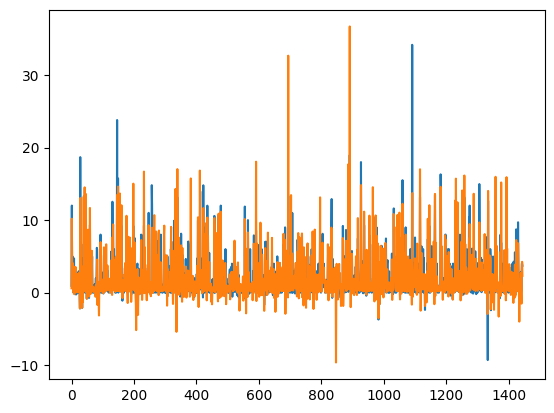

In [155]:
plt.plot(torch.tensor(Yhat_test_IPOPT[:, :data.ng]).mean(dim=0))

plt.plot(Yhat_valid[:, :data.ng].mean(dim=0))

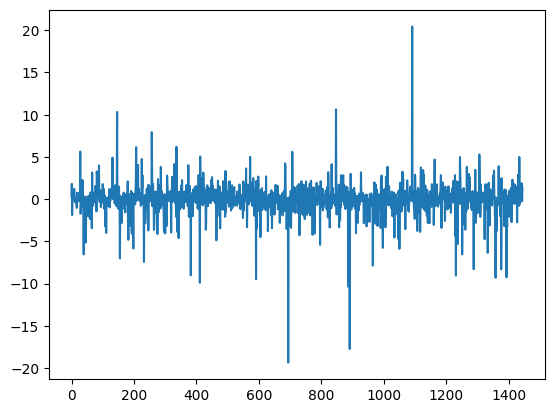

In [187]:
plt.plot((torch.tensor(Yhat_test_IPOPT[:, :data.ng]).mean(dim=0) - Yhat_valid[:, :data.ng].mean(dim=0)))


In [64]:
model.display()

Model unknown

  Variables:
    pg : Size=1444, Index=gen_buses
        Key  : Lower : Value                   : Upper : Fixed : Stale : Domain
           1 :  None :      0.8874696614684341 :  None : False : False :  Reals
           5 :  None :      11.999999580895475 :  None : False : False :  Reals
           7 :  None :      1.6416979281784372 :  None : False : False :  Reals
          17 :  None :       5.000031061103817 :  None : False : False :  Reals
          24 :  None :       3.040353022951086 :  None : False : False :  Reals
          31 :  None :     0.16204401800302048 :  None : False : False :  Reals
          32 :  None : -6.1501052792052056e-06 :  None : False : False :  Reals
          38 :  None :    0.004401977882549593 :  None : False : False :  Reals
          48 :  None :       4.799997629827319 :  None : False : False :  Reals
          50 :  None :      1.0000051380610175 :  None : False : False :  Reals
          79 :  None :      1.0000116566579869 :  None :

In [65]:
# def create_model(nominal_Psqrt, nominal_q, nominal_A, nominal_b, nominal_G, nominal_h):
#     # Create a concrete model
#     m = pyo.ConcreteModel()

#     m.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
#     m.ipopt_zL_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
#     m.ipopt_zU_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
#     n = nominal_Psqrt.shape[0]
#     t = nominal_A.shape[0]
#     p = nominal_G.shape[0]
    
#     # Define parameters
#     m.Psqrt = pyo.Var(range(n), range(n), within=pyo.Reals, 
#                 initialize={(i, j): nominal_Psqrt[i, j] for i in range(n) for j in range(n)})
#     # set lower/upper bounds
#     for i in range(n):
#         for j in range(n):
#             m.Psqrt[i, j].setlb(nominal_Psqrt[i, j])
#             m.Psqrt[i, j].setub(nominal_Psqrt[i, j])
            
#     m.q = pyo.Var(range(n), within=pyo.Reals,
#                     initialize={i: nominal_q[i] for i in range(n)})            # Linear term vector
#     for i in range(n):
#         m.q[i].setlb(nominal_q[i])
    
#     m.A = pyo.Var(range(t), range(n), within=pyo.Reals,
#                      initialize={(i, j): nominal_A[i, j] for i in range(t) for j in range(n)})  # Equality constraint matrix
#     for i in range(t):
#         for j in range(n):
#             m.A[i, j].setlb(nominal_A[i, j])
#             m.A[i, j].setub(nominal_A[i, j])

                        
#     m.b = pyo.Var(range(t), within=pyo.Reals, 
#                     initialize={i: nominal_b[i] for i in range(t)})     # Equality constraint vector
#     for i in range(t):
#         m.b[i].setlb(nominal_b[i]) 
#         m.b[i].setub(nominal_b[i])  
        
#     m.G = pyo.Var(range(p), range(n), within=pyo.Reals, 
#                     initialize={(i, j): nominal_G[i, j] for i in range(p) for j in range(n)})  # Inequality constraint matrix
#     for i in range(p):
#         for j in range(n):
#              m.G[i, j].setlb(nominal_G[i, j])
#              m.G[i, j].setub(nominal_G[i, j])

#     m.h = pyo.Var(range(p), within=pyo.Reals, 
#                     initialize={i: nominal_h[i] for i in range(p)}) 
#     for i in range(p):
#         m.h[i].setlb(nominal_h[i])  
#         m.h[i].setub(nominal_h[i])  
    
#     # Define variables
#     m.x = pyo.Var(range(n), within=pyo.Reals)

#     # Define equality constraints
#     m.equ_constraints = pyo.ConstraintList()
#     for i in range(t):
#         m.equ_constraints.add(sum(m.A[i, j] * m.x[j] for j in range(n)) == m.b[i])

#     # Define inequality constraints
#     m.inequ_constraints = pyo.ConstraintList()
#     for i in range(p):
#         m.inequ_constraints.add(sum(m.G[i, j] * m.x[j] for j in range(n)) - m.h[i] <= 0)
    
#     # Define objective function: 
#     def objective_rule(m):
#         tol_term = 0
#         for i in range(n):
#             q_term = 0
#             for j in range(n):
#                 q_term += m.Psqrt[i, j] * m.x[j]
#             tol_term += q_term**2
            
#         return 0.5 * tol_term + sum(m.q[i] * m.x[i] for i in range(n))
        
#     m.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)
     
#     return m

# n, t, p = 10, 5, 2
# np.random.seed(0)
# nominal_Psqrt = np.abs(np.random.rand(n, n))
# nominal_q = np.random.rand(n)
# nominal_A = np.random.rand(t, n)
# nominal_b = np.random.rand(t)
# nominal_G = np.random.rand(p, n)
# nominal_h = np.random.rand(p)

# model = create_model(nominal_Psqrt, nominal_q, nominal_A, nominal_b, nominal_G, nominal_h)
# opt = pyo.SolverFactory('ipopt', tee=True)
# results = opt.solve(model) 
# print(results)
# #model.pprint()
# print(model.obj())

In [194]:
# def create_model(nominal_Psqrt, nominal_q, nominal_A, nominal_b, nominal_G, nominal_h):
#     # Create a concrete model
#     m = pyo.ConcreteModel()

#     m.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
#     m.ipopt_zL_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
#     m.ipopt_zU_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
#     # Define variables
#     m.x = pyo.Var(range(n), within=pyo.Reals)
    
#     # Define parameters
#     m.Psqrt = pyo.Var(range(n), range(n), within=pyo.Reals)
#     m.q = pyo.Var(range(n), within=pyo.Reals)            # Linear term vector
#     m.A = pyo.Var(range(t), range(n), within=pyo.Reals)  # Equality constraint matrix
#     m.b = pyo.Var(range(t), within=pyo.Reals)            # Equality constraint vector
#     m.G = pyo.Var(range(p), range(n), within=pyo.Reals)  # Inequality constraint matrix
#     m.h = pyo.Var(range(p), within=pyo.Reals) 
    
#     for i in range(n):
#         for j in range(n):
#             m.Psqrt[i, j].fix(nominal_Psqrt[i, j])

#     for i in range(n):
#         m.q[i].fix(nominal_q[i])
    
#     for i in range(t):
#         for j in range(n):
#             m.A[i, j].fix(nominal_A[i, j])
            
#     for i in range(t):  
#         m.b[i].fix(nominal_b[i])

#     for i in range(p):
#         for j in range(n):
#             m.G[i, j].fix(nominal_G[i, j])

#     for i in range(p):
#         m.h[i].fix(nominal_h[i])

    
#     # Define equality constraints
#     m.equ_constraints = pyo.ConstraintList()
#     for i in range(t):
#         m.equ_constraints.add(sum(m.A[i, j] * m.x[j] for j in range(n)) == m.b[i])

#     # Define inequality constraints
#     m.inequ_constraints = pyo.ConstraintList()
#     for i in range(p):
#         m.inequ_constraints.add(sum(m.G[i, j] * m.x[j] for j in range(n)) - m.h[i] <= 0)
    
#     # Define objective function: 
#     def objective_rule(m):
#         tol_term = 0
#         for i in range(n):
#             q_term = 0
#             for j in range(n):
#                 q_term += m.Psqrt[i, j] * m.x[j]
#             tol_term += q_term**2
            
#         return 0.5 * tol_term + sum(m.q[i] * m.x[i] for i in range(n))
        
#     m.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)
     
#     return m

# n,t,p = 10, 5, 2
# np.random.seed(0)
# nominal_Psqrt = np.random.rand(n, n)
# nominal_q = np.random.rand(n)

# nominal_A = np.random.rand(t, n)
# nominal_b = np.random.rand(t)
# nominal_G = np.random.rand(p, n)
# nominal_h = np.random.rand(p)

# model = create_model(nominal_Psqrt, nominal_q, nominal_A, nominal_b, nominal_G, nominal_h)
# opt = pyo.SolverFactory('ipopt', tee=True)
# results = opt.solve(model) 
# print(results)
# #model.pprint()
# print(model.obj())

In [195]:
# nominal_pg, nominal_qg, nominal_vm, nominal_va = data.get_yvars(data.Y[0:1, :])
# nominal_pg_test = torch.tensor(nominal_pg[:, data.pv_], requires_grad=True)
# nominal_vg_test = torch.tensor(nominal_vm[:, data.spv], requires_grad=True)

# nominal_pd_test = torch.tensor(np.array(data.X[0:1, :data.nbus]))
# nominal_qd_test = torch.tensor(np.array(data.X[0:1, data.nbus:data.nbus*2]))
         
# input = tuple([nominal_pg_test, nominal_vg_test, nominal_pd_test, nominal_qd_test])

# primal_batch, slack_out, _,  _, _ = Layer(*input)


In [26]:
variables_name = [model.vm, model.va, model.pg_ref, model.qg, model.qg_ref, model.vg, model.pg]
parameters_name = [model.pg_slack, model.vg_slack]
parameters_known = [model.pd, model.qd]
slacks_name = None
free_parameters_name = None
Layer = PyomoOptLayer(model, variables_name, parameters_name, free_parameters_name, parameters_known, slacks_name)

In [27]:
trainX_new = data.trainX
validX_new = data.validX
testX_new = data.testX

trainY_new = data.trainY
validY_new = data.validY
testY_new = data.testY

print(trainX_new.shape)
print(validX_new.shape)
print(testY_new.shape)

solver_step = args['lr']
nepochs = args['epochs']
batch_size = args['batchSize']

train_dataset = TensorDataset(trainX_new, trainY_new)
valid_dataset = TensorDataset(validX_new, validY_new)
test_dataset = TensorDataset(testX_new, testY_new)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

torch.Size([140, 18482])
torch.Size([20, 18482])
torch.Size([40, 21372])


In [28]:
class NNSolver(nn.Module):
    def __init__(self, data, args):
        super().__init__()
        self._data = data
        self._args = args
        self.layers1 = nn.Linear(data.nbus*2, self._args['hiddenSize'])
        self.relu = nn.ReLU(inplace=True)
        self.layers2 = nn.Linear(self._args['hiddenSize'], data.npv * 2 + 1)
        self.layers3 = nn.Linear(self._args['hiddenSize'], self._args['hiddenSize'])
        
    def forward(self, x):

        out = self.layers1(x)
        
        out = self.relu(out)

        out = self.layers3(out)
        
        out = self.relu(out)

        out = self.layers2(out)

        out = nn.Tanh()(out)   # used to interpolate between max and min values

        return out

In [29]:
obj_weight = 1

solver_net = NNSolver(data, args)
solver_opt = optim.Adam(solver_net.parameters(), lr=solver_step)
scheduler = torch.optim.lr_scheduler.MultiStepLR(solver_opt, milestones=[90], gamma=1)

stats = {}
batch_loss = []
epoch_loss = []

batch_loss_super = []
epoch_loss_super = []

batch_loss_unsuper = []
epoch_loss_unsuper = []

In [170]:
# checkpoint = torch.load('model_checkpoint.pth')  # add map_location='cpu' if loading on CPU
# solver_net.load_state_dict(checkpoint['model_state_dict'])
# solver_opt.load_state_dict(checkpoint['optimizer_state_dict'])

In [50]:
for i in range(10):
    epoch_stats = {}
    
    # Get train loss
    solver_net.train()
    Layer.train()
    for Xtrain, Ytrain in train_loader:

        pg_train, _, vm_train, va_train = data.get_yvars(Ytrain)

        solver_opt.zero_grad()

        Yhat_train_partial = solver_net(Xtrain) 

        Yhat_train_partial_trans = data.complete_partial_tanh(Xtrain, Yhat_train_partial) #used to satisfy the voltage magnitude constraints
        
        if i < 0:
            pg, _, vm, _ = data.get_yvars(Ytrain)
            Ytrain_partial = torch.cat((pg[:, data.pv_], vm[:, data.spv]), 1)
            train_loss = torch.norm(Yhat_train_partial_trans -  Ytrain_partial)
        else:
            input = tuple([Yhat_train_partial_trans[:, :data.npv], Yhat_train_partial_trans[:, data.npv:], Xtrain[:, :data.nbus], Xtrain[:, data.nbus:]])
            primal_batch, slack_out, _,  _, _, _ = Layer(*input)
            # model.vm, model.va, model.pg_ref, model.qg, model.qg_ref, model.vg, model.pg
            Yhat_train = torch.zeros(Xtrain.shape[0], data.ydim)
            # pg given by the NN
            # pg_slack:
            pg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng + data.npv]
            Yhat_train[:, data.pv_] = pg_slack
            # pg_ref
            Yhat_train[:, data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes):len(data.pq) + len(data.nonslack_idxes)+1]
            # pg_ref_slack
            # pg_ref_slack = primal_batch[:, -2:-1]
            # qg
            Yhat_train[:, data.ng + data.pv_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes)+1:len(data.pq) + len(data.nonslack_idxes) + 1 + data.npv]
            # qg_ref
            Yhat_train[:, data.ng + data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1]
            # vm 
            Yhat_train[:, data.ng*2+data.pq] = primal_batch[:, :len(data.pq)]
            # vg
            vg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng]
            Yhat_train[:, data.ng*2+data.spv] = vg_slack
            # va
            Yhat_train[:, data.ng*2+data.nbus+data.nonslack_idxes] = primal_batch[:, len(data.pq):len(data.pq) + len(data.nonslack_idxes)]
            Yhat_train[:, data.ng*2+data.nbus+data.slack.item()] = slackva.item()
            # va
            pg_slack_ref_diff = torch.norm((Yhat_train_partial_trans[:, :data.npv] - pg_slack), dim =1) +\
                                torch.norm((Yhat_train_partial_trans[:, data.npv:] - vg_slack), dim =1)

            # Pf, Qf = data.eq_resid_bf(Xtrain, Yhat_train)
            # sij = torch.square(Pf) + torch.square(Qf)
            # calculate the branch flow
            pg_all = torch.zeros(Xtrain.shape[0], data.ng)
            pg_all[:, data.pv_] = Yhat_train_partial_trans[:, :data.npv]
            pg_all[:, data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes):len(data.pq) + len(data.nonslack_idxes)+1]
            obj_cost = data.gen_cost(pg_all).mean() 

            if slack_out is not None:
                unsupervised_loss = torch.mean(torch.abs(slack_out)) + torch.norm(data.ineq_dist(Xtrain, Yhat_train), dim=1).mean() 
                train_loss = obj_weight * obj_cost + unsupervised_loss + 10 * pg_slack_ref_diff.mean()
            else:
                unsupervised_loss = torch.norm(data.ineq_dist_Pg(Xtrain, Yhat_train), dim=1).mean() 
                train_loss = obj_weight * obj_cost + unsupervised_loss + 10 * pg_slack_ref_diff.mean()
            
        train_loss.backward()
        solver_opt.step()

        batch_loss.append(train_loss.detach().cpu().numpy())
        batch_loss_super.append(pg_slack_ref_diff.mean().detach().cpu().numpy())
        try:
            batch_loss_unsuper.append(unsupervised_loss.detach().cpu().numpy())
        except:
            batch_loss_unsuper.append(0.0)

    # scheduler.step()
    # Get valid loss
    solver_net.eval()
    Layer.eval()
    start_time_eval = time.time()
    with torch.no_grad():
        for Xvalid, Yvalid in valid_loader:
            Yhat_valid_partial = solver_net(Xvalid).detach()
            Yhat_valid_partial_trans = data.complete_partial_tanh(Xvalid, Yhat_valid_partial)
            # Yhat_valid = PFFunction_eval(data)(Xvalid, Yhat_valid_partial_trans)
            # unsupervised_loss_valid = 0
            input = tuple([Yhat_valid_partial_trans[:, :data.npv], Yhat_valid_partial_trans[:, data.npv:], Xvalid[:, :data.nbus], Xvalid[:, data.nbus:]])
            primal_batch, _, _,  _, _, _ = Layer(*input)
            eval_time = time.time() - start_time_eval  
            Yhat_valid = torch.zeros(Xvalid.shape[0], data.ydim)
            pg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng + data.npv]
            Yhat_valid[:, data.pv_] = pg_slack
            # pg_ref
            Yhat_valid[:, data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes):len(data.pq) + len(data.nonslack_idxes)+1]
            # pg_ref_slack
            # pg_ref_slack = primal_batch[:, -2:-1]
            # qg
            Yhat_valid[:, data.ng + data.pv_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes)+1:len(data.pq) + len(data.nonslack_idxes) + 1 + data.npv]
            # qg_ref
            Yhat_valid[:, data.ng + data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1]
            # qg_ref_slack
            # qg_ref_slack = primal_batch[:, -1:]
            # vm 
            Yhat_valid[:, data.ng*2+data.pq] = primal_batch[:, :len(data.pq)]
            # vg
            vg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng]
            Yhat_valid[:, data.ng*2+data.spv] = vg_slack
            # va
            Yhat_valid[:, data.ng*2+data.nbus+data.nonslack_idxes] = primal_batch[:, len(data.pq):len(data.pq) + len(data.nonslack_idxes)]
            Yhat_valid[:, data.ng*2+data.nbus+data.slack.item()] = slackva.item()
            Pf, Qf = data.eq_resid_bf(Xvalid, Yhat_valid)
            sij = torch.square(Pf) + torch.square(Qf)
            pg_slack_ref_diff = torch.norm((Yhat_valid_partial_trans[:, :data.npv] - pg_slack), dim =1) +\
                                torch.norm((Yhat_valid_partial_trans[:, data.npv:] - vg_slack), dim =1)
                                # torch.norm((pg_ref_slack - Yhat_valid[:, data.slack_]), dim =1) +\
                                # torch.norm((qg_ref_slack - Yhat_valid[:, data.ng + data.slack_]), dim =1)

        eval_net(data, Xvalid, Yhat_valid, sij, bounded_branch, args, 'valid', epoch_stats)
    eval_time = time.time() - start_time_eval  
    print("eval_time", eval_time )
    print(
        'Epoch {}: train loss {:.4f}, train unsup loss {:.8f}, eval {:.4f}, ineq max {:.8f}, ineq mean {:.8f}, ineq num viol {:.2f}, valid_unsup loss {:.8f}'.format(
            i, np.mean(batch_loss), np.mean(batch_loss_unsuper), np.mean(epoch_stats['valid_eval']), np.mean(epoch_stats['valid_ineq_max']),
            np.mean(epoch_stats['valid_ineq_mean']), np.mean(epoch_stats['valid_ineq_num_viol_0']), pg_slack_ref_diff.mean()))
    
    epoch_loss.append(np.mean(batch_loss))
    epoch_loss_unsuper.append(np.mean(batch_loss_unsuper))
    epoch_loss_super.append(np.mean(batch_loss_super))

    batch_loss = []
    batch_loss_unsuper = []
    batch_loss_super = []
    torch.save({
    'model_state_dict': solver_net.state_dict(),
    'optimizer_state_dict': solver_opt.state_dict()}, "checkpoint_1obj_pgvg_118bus.pth")

eval_time 286.44253420829773
Epoch 0: train loss 63.6416, train unsup loss 0.25690613, eval 29.6396, ineq max 0.13170790, ineq mean 0.00024151, ineq num viol 142.00, valid_unsup loss 5.35026550
eval_time 3190.5874288082123
Epoch 1: train loss 72.3489, train unsup loss 0.44838474, eval 30.0079, ineq max 0.10890900, ineq mean 0.00010712, ineq num viol 60.25, valid_unsup loss 5.43572343
eval_time 237.89924788475037
Epoch 2: train loss 68.7235, train unsup loss 0.30085490, eval 31.4632, ineq max 0.04671272, ineq mean 0.00002535, ineq num viol 24.50, valid_unsup loss 3.14004811


python(10562) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10659) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10689) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10796) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10895) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(10998) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11160) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11230) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11320) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11514) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11587) Malloc

KeyboardInterrupt: 

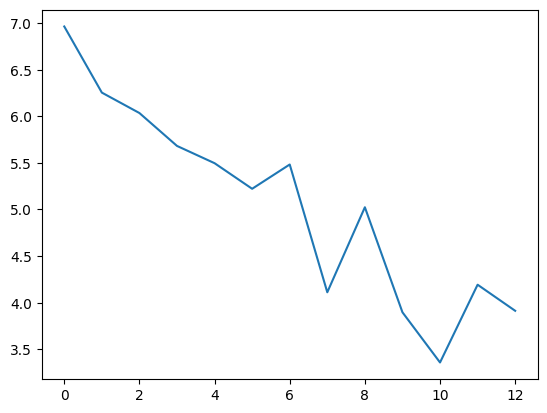

In [51]:
plt.plot(epoch_loss_super)

In [52]:
# generate the dataset and retrain it
solver_net.eval()
Layer.eval()
start_time_eval = time.time()
with torch.no_grad():
    for Xvalid, Yvalid in test_loader:
        Yhat_valid_partial = solver_net(Xvalid).detach()
        Yhat_valid_partial_trans = data.complete_partial_tanh(Xvalid, Yhat_valid_partial)
        # Yhat_valid = PFFunction_eval(data)(Xvalid, Yhat_valid_partial_trans)
        # unsupervised_loss_valid = 0
        # model.vm, model.va, model.pg_ref, model.qg, model.qg_ref, model.vg, model.pg
        input = tuple([Yhat_valid_partial_trans[:, :data.npv], Yhat_valid_partial_trans[:, data.npv:], Xvalid[:, :data.nbus], Xvalid[:, data.nbus:]])
        primal_batch, _, _,  _, _, J = Layer(*input)
        Yhat_valid = torch.zeros(Xvalid.shape[0], data.ydim)
        pg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng + data.npv]
        Yhat_valid[:, data.pv_] = pg_slack
        # pg_ref
        Yhat_valid[:, data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes):len(data.pq) + len(data.nonslack_idxes)+1]
        # pg_ref_slack
        # pg_ref_slack = primal_batch[:, -2:-1]
        # qg
        Yhat_valid[:, data.ng + data.pv_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes)+1:len(data.pq) + len(data.nonslack_idxes) + 1 + data.npv]
        # qg_ref
        Yhat_valid[:, data.ng + data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1]
        # qg_ref_slack
        # qg_ref_slack = primal_batch[:, -1:]
        # vm 
        Yhat_valid[:, data.ng*2+data.pq] = primal_batch[:, :len(data.pq)]
        # vg
        vg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng]
        Yhat_valid[:, data.ng*2+data.spv] = vg_slack
        # va
        Yhat_valid[:, data.ng*2+data.nbus+data.nonslack_idxes] = primal_batch[:, len(data.pq):len(data.pq) + len(data.nonslack_idxes)]
        Yhat_valid[:, data.ng*2+data.nbus+data.slack.item()] = slackva.item()
        eval_time = time.time() - start_time_eval 
        Pf, Qf = data.eq_resid_bf(Xvalid, Yhat_valid)
        sij = torch.square(Pf) + torch.square(Qf)
        pg_slack_ref_diff = torch.norm((Yhat_valid_partial_trans[:, :data.npv] - pg_slack), dim =1) +\
                            torch.norm((Yhat_valid_partial_trans[:, data.npv:] - vg_slack), dim =1)
    eval_net(data, Xvalid, Yhat_valid, sij, bounded_branch, args, 'valid', epoch_stats)
print(eval_time)

python(11905) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11951) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11981) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(11996) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(12122) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(12183) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(12212) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(12225) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(12227) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(12312) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(12328) Malloc

489.6731491088867


In [53]:
print('Epoch {}: train loss {:.4f}, train unsup loss {:.8f}, eval {:.4f}, ineq max {:.8f}, ineq mean {:.8f}, ineq num viol {:.2f}, valid_unsup loss {:.8f}'.format(
            i, np.mean(batch_loss), np.mean(batch_loss_unsuper), np.mean(epoch_stats['valid_eval']), np.mean(epoch_stats['valid_ineq_max']),
            np.mean(epoch_stats['valid_ineq_mean']), np.mean(epoch_stats['valid_ineq_num_viol_0']), pg_slack_ref_diff.mean()))

Epoch 3: train loss 62.7690, train unsup loss 0.22971209, eval 29.2558, ineq max 0.05278093, ineq mean 0.00004285, ineq num viol 44.60, valid_unsup loss 3.11309511


In [54]:
pgmin = data.ineq_dist(Xvalid, Yhat_valid)[:, :data.ng]
print(pgmin.max())

pgmax = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng:data.ng*2]
print(pgmax.max())

qgmin = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng*2:data.ng*3]
print(qgmin.max())

qgmax = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng*3:data.ng*4]
print(qgmax.max())

vmin = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng*4:data.ng*4 + data.nbus]
print(vmin.max())
vmax = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng*4 + data.nbus:data.ng*4 + data.nbus*2]

print(vmax.max())

Pf, Qf = data.eq_resid_bf(Xvalid, Yhat_valid)
sij = torch.square(Pf) + torch.square(Qf)
sij_max = data.ineq_dist_bf(Xvalid, Yhat_valid, sij, bounded_branch)[:, data.ng*4 + data.nbus*2:]
print(sij_max.max())

# print((28.8685 - 28.77445432217217) / 28.77445432217217 * 100)

print("vio ratio", torch.sum(data.ineq_dist_bf(Xvalid, Yhat_valid, sij, bounded_branch) > 1e-7, dim=1).detach().cpu().numpy().mean() / data.ineq_dist_bf(Xvalid, Yhat_valid, sij, bounded_branch).shape[1])

tensor(0.1047)
tensor(0.2378)
tensor(5.3202e-08)
tensor(0.)
tensor(1.0893e-08)
tensor(9.9326e-09)
tensor(1.9758e-06)
vio ratio 0.0008839039850366291


In [ ]:
# How to train it


In [73]:
for i in range(10):
    epoch_stats = {}
    
    # Get train loss
    solver_net.train()
    Layer.train()
    for Xtrain, Ytrain in train_loader:

        pg_train, _, vm_train, va_train = data.get_yvars(Ytrain)

        solver_opt.zero_grad()

        Yhat_train_partial = solver_net(Xtrain) 

        Yhat_train_partial_trans = data.complete_partial_tanh(Xtrain, Yhat_train_partial) #used to satisfy the voltage magnitude constraints
        
        if i < 0:
            pg, _, vm, _ = data.get_yvars(Ytrain)
            Ytrain_partial = torch.cat((pg[:, data.pv_], vm[:, data.spv]), 1)
            train_loss = torch.norm(Yhat_train_partial_trans -  Ytrain_partial)
        else:
            input = tuple([Yhat_train_partial_trans[:, :data.npv], Yhat_train_partial_trans[:, data.npv:], Xtrain[:, :data.nbus], Xtrain[:, data.nbus:]])
            primal_batch, slack_out, _,  _, _ = Layer(*input)
            # model.vm, model.va, model.pg_ref, model.qg, model.qg_ref, model.vg, model.pg
            Yhat_train = torch.zeros(Xtrain.shape[0], data.ydim)
            # pg given by the NN
            # pg_slack:
            pg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng + data.npv]
            Yhat_train[:, data.pv_] = pg_slack
            # pg_ref
            Yhat_train[:, data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes):len(data.pq) + len(data.nonslack_idxes)+1]
            # pg_ref_slack
            # pg_ref_slack = primal_batch[:, -2:-1]
            # qg
            Yhat_train[:, data.ng + data.pv_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes)+1:len(data.pq) + len(data.nonslack_idxes) + 1 + data.npv]
            # qg_ref
            Yhat_train[:, data.ng + data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1]
            # vm 
            Yhat_train[:, data.ng*2+data.pq] = primal_batch[:, :len(data.pq)]
            # vg
            vg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng]
            Yhat_train[:, data.ng*2+data.spv] = vg_slack
            # va
            Yhat_train[:, data.ng*2+data.nbus+data.nonslack_idxes] = primal_batch[:, len(data.pq):len(data.pq) + len(data.nonslack_idxes)]
            Yhat_train[:, data.ng*2+data.nbus+data.slack.item()] = slackva.item()
            # va
            pg_slack_ref_diff = torch.norm((Yhat_train_partial_trans[:, :data.npv] - pg_slack), dim =1) +\
                                torch.norm((Yhat_train_partial_trans[:, data.npv:] - vg_slack), dim =1)

            Pf, Qf = data.eq_resid_bf(Xtrain, Yhat_train)
            sij = torch.square(Pf) + torch.square(Qf)
            # calculate the branch flow
            pg_all = torch.zeros(Xtrain.shape[0], data.ng)
            pg_all[:, data.pv_] = Yhat_train_partial_trans[:, :data.npv]
            pg_all[:, data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes):len(data.pq) + len(data.nonslack_idxes)+1]
            obj_cost = data.gen_cost(pg_all).mean() 

            if slack_out is not None:
                unsupervised_loss = torch.mean(torch.abs(slack_out)) + torch.norm(data.ineq_dist(Xtrain, Yhat_train), dim=1).mean() 
                train_loss = obj_weight * obj_cost + unsupervised_loss + pg_slack_ref_diff.mean()
            else:
                unsupervised_loss = torch.norm(data.ineq_dist_Pg(Xtrain, Yhat_train), dim=1).mean() 
                train_loss = obj_weight * obj_cost + unsupervised_loss + pg_slack_ref_diff.mean()
            
        train_loss.backward()
        solver_opt.step()

        batch_loss.append(train_loss.detach().cpu().numpy())
        try:
            batch_loss_unsuper.append(unsupervised_loss.detach().cpu().numpy())
        except:
            batch_loss_unsuper.append(0.0)

    # scheduler.step()
    # Get valid loss
    solver_net.eval()
    Layer.eval()
    start_time_eval = time.time()
    with torch.no_grad():
        for Xvalid, Yvalid in valid_loader:
            Yhat_valid_partial = solver_net(Xvalid).detach()
            Yhat_valid_partial_trans = data.complete_partial_tanh(Xvalid, Yhat_valid_partial)
            # Yhat_valid = PFFunction_eval(data)(Xvalid, Yhat_valid_partial_trans)
            # unsupervised_loss_valid = 0
            input = tuple([Yhat_valid_partial_trans[:, :data.npv], Yhat_valid_partial_trans[:, data.npv:], Xvalid[:, :data.nbus], Xvalid[:, data.nbus:]])
            primal_batch, _, _,  _, _ = Layer(*input)
            eval_time = time.time() - start_time_eval  
            Yhat_valid = torch.zeros(Xvalid.shape[0], data.ydim)
            pg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng + data.npv]
            Yhat_valid[:, data.pv_] = pg_slack
            # pg_ref
            Yhat_valid[:, data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes):len(data.pq) + len(data.nonslack_idxes)+1]
            # pg_ref_slack
            # pg_ref_slack = primal_batch[:, -2:-1]
            # qg
            Yhat_valid[:, data.ng + data.pv_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes)+1:len(data.pq) + len(data.nonslack_idxes) + 1 + data.npv]
            # qg_ref
            Yhat_valid[:, data.ng + data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1]
            # qg_ref_slack
            # qg_ref_slack = primal_batch[:, -1:]
            # vm 
            Yhat_valid[:, data.ng*2+data.pq] = primal_batch[:, :len(data.pq)]
            # vg
            vg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng]
            Yhat_valid[:, data.ng*2+data.spv] = vg_slack
            # va
            Yhat_valid[:, data.ng*2+data.nbus+data.nonslack_idxes] = primal_batch[:, len(data.pq):len(data.pq) + len(data.nonslack_idxes)]
            Yhat_valid[:, data.ng*2+data.nbus+data.slack.item()] = slackva.item()
            Pf, Qf = data.eq_resid_bf(Xvalid, Yhat_valid)
            sij = torch.square(Pf) + torch.square(Qf)
            pg_slack_ref_diff = torch.norm((Yhat_valid_partial_trans[:, :data.npv] - pg_slack), dim =1) +\
                                torch.norm((Yhat_valid_partial_trans[:, data.npv:] - vg_slack), dim =1)
                                # torch.norm((pg_ref_slack - Yhat_valid[:, data.slack_]), dim =1) +\
                                # torch.norm((qg_ref_slack - Yhat_valid[:, data.ng + data.slack_]), dim =1)

        eval_net(data, Xvalid, Yhat_valid, sij, bounded_branch, args, 'valid', epoch_stats)
    eval_time = time.time() - start_time_eval  
    print("eval_time", eval_time )
    print(
        'Epoch {}: train loss {:.4f}, train unsup loss {:.8f}, eval {:.4f}, ineq max {:.8f}, ineq mean {:.8f}, ineq num viol {:.2f}, valid_unsup loss {:.8f}'.format(
            i, np.mean(batch_loss), np.mean(batch_loss_unsuper), np.mean(epoch_stats['valid_eval']), np.mean(epoch_stats['valid_ineq_max']),
            np.mean(epoch_stats['valid_ineq_mean']), np.mean(epoch_stats['valid_ineq_num_viol_0']), pg_slack_ref_diff.mean()))
    
    epoch_loss.append(np.mean(batch_loss))
    epoch_loss_unsuper.append(np.mean(batch_loss_unsuper))
    
    batch_loss = []
    batch_loss_unsuper = []
    torch.save({
    'model_state_dict': solver_net.state_dict(),
    'optimizer_state_dict': solver_opt.state_dict()}, "checkpoint_001obj_pgvg.pth")

eval_time 271.0394859313965
Epoch 0: train loss 10.9730, train unsup loss 0.90752929, eval 28.6804, ineq max 0.09560913, ineq mean 0.00004854, ineq num viol 57.50, valid_unsup loss 5.20763670
eval_time 305.414306640625
Epoch 1: train loss 9.7544, train unsup loss 0.59854295, eval 29.5074, ineq max 0.14173033, ineq mean 0.00012201, ineq num viol 86.25, valid_unsup loss 6.56162263
eval_time 318.84965777397156
Epoch 2: train loss 9.3056, train unsup loss 0.53864429, eval 28.3600, ineq max 0.29894636, ineq mean 0.00007040, ineq num viol 86.00, valid_unsup loss 4.88645426
eval_time 268.28084421157837
Epoch 3: train loss 8.8371, train unsup loss 0.46184951, eval 30.6928, ineq max 0.15134738, ineq mean 0.00013858, ineq num viol 76.75, valid_unsup loss 6.71334823
eval_time 261.43744373321533
Epoch 4: train loss 7.9757, train unsup loss 0.35826519, eval 29.0706, ineq max 0.06733769, ineq mean 0.00004924, ineq num viol 43.25, valid_unsup loss 3.47210890
eval_time 288.08468794822693
Epoch 5: trai

In [190]:
# generate the dataset and retrain it
solver_net.eval()
Layer.eval()
start_time_eval = time.time()
with torch.no_grad():
    for Xvalid, Yvalid in test_loader:
        Yhat_valid_partial = solver_net(Xvalid).detach()
        Yhat_valid_partial_trans = data.complete_partial_tanh(Xvalid, Yhat_valid_partial)
        # Yhat_valid = PFFunction_eval(data)(Xvalid, Yhat_valid_partial_trans)
        # unsupervised_loss_valid = 0
        # model.vm, model.va, model.pg_ref, model.qg, model.qg_ref, model.vg, model.pg
        input = tuple([Yhat_valid_partial_trans[:, :data.npv], Yhat_valid_partial_trans[:, data.npv:], Xvalid[:, :data.nbus], Xvalid[:, data.nbus:]])
        primal_batch, _, _,  _, _ = Layer(*input)
        Yhat_valid = torch.zeros(Xvalid.shape[0], data.ydim)
        pg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng + data.npv]
        Yhat_valid[:, data.pv_] = pg_slack
        # pg_ref
        Yhat_valid[:, data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes):len(data.pq) + len(data.nonslack_idxes)+1]
        # pg_ref_slack
        # pg_ref_slack = primal_batch[:, -2:-1]
        # qg
        Yhat_valid[:, data.ng + data.pv_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes)+1:len(data.pq) + len(data.nonslack_idxes) + 1 + data.npv]
        # qg_ref
        Yhat_valid[:, data.ng + data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1]
        # qg_ref_slack
        # qg_ref_slack = primal_batch[:, -1:]
        # vm 
        Yhat_valid[:, data.ng*2+data.pq] = primal_batch[:, :len(data.pq)]
        # vg
        vg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng]
        Yhat_valid[:, data.ng*2+data.spv] = vg_slack
        # va
        Yhat_valid[:, data.ng*2+data.nbus+data.nonslack_idxes] = primal_batch[:, len(data.pq):len(data.pq) + len(data.nonslack_idxes)]
        Yhat_valid[:, data.ng*2+data.nbus+data.slack.item()] = slackva.item()
        eval_time = time.time() - start_time_eval 
        Pf, Qf = data.eq_resid_bf(Xvalid, Yhat_valid)
        sij = torch.square(Pf) + torch.square(Qf)
        pg_slack_ref_diff = torch.norm((Yhat_valid_partial_trans[:, :data.npv] - pg_slack), dim =1) +\
                            torch.norm((Yhat_valid_partial_trans[:, data.npv:] - vg_slack), dim =1)
    eval_net(data, Xvalid, Yhat_valid, sij, bounded_branch, args, 'valid', epoch_stats)
print(eval_time)

433.3453838825226


In [191]:
print('Epoch {}: train loss {:.4f}, train unsup loss {:.8f}, eval {:.4f}, ineq max {:.8f}, ineq mean {:.8f}, ineq num viol {:.2f}, valid_unsup loss {:.8f}'.format(
            i, np.mean(batch_loss), np.mean(batch_loss_unsuper), np.mean(epoch_stats['valid_eval']), np.mean(epoch_stats['valid_ineq_max']),
            np.mean(epoch_stats['valid_ineq_mean']), np.mean(epoch_stats['valid_ineq_num_viol_0']), pg_slack_ref_diff.mean()))

Epoch 39: train loss nan, train unsup loss nan, eval 29.2534, ineq max 0.06603105, ineq mean 0.00003464, ineq num viol 34.63, valid_unsup loss 3.70313024


/Users/kchen2/anaconda3/envs/OPT_layer_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/kchen2/anaconda3/envs/OPT_layer_env/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [192]:
pgmin = data.ineq_dist(Xvalid, Yhat_valid)[:, :data.ng]
print(pgmin.max())

pgmax = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng:data.ng*2]
print(pgmax.max())

qgmin = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng*2:data.ng*3]
print(qgmin.max())

qgmax = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng*3:data.ng*4]
print(qgmax.max())

vmin = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng*4:data.ng*4 + data.nbus]
print(vmin.max())
vmax = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng*4 + data.nbus:data.ng*4 + data.nbus*2]

print(vmax.max())

Pf, Qf = data.eq_resid_bf(Xvalid, Yhat_valid)
sij = torch.square(Pf) + torch.square(Qf)
sij_max = data.ineq_dist_bf(Xvalid, Yhat_valid, sij, bounded_branch)[:, data.ng*4 + data.nbus*2:]
print(sij_max.max())

tensor(0.1902)
tensor(0.1618)
tensor(3.2220e-08)
tensor(0.)
tensor(1.0736e-08)
tensor(9.7743e-09)
tensor(1.5453e-06)


1445

In [239]:
(29.25 - 28.77445432217217) / 28.77445432217217 * 100

0.8533460794028882

In [30]:
Yhat_valid_newton = PFFunction_eval(data)(Xvalid, Yhat_valid_partial_trans)

#equality 
equality_mismatch = data.eq_resid(Xvalid, Yhat_valid_newton).detach()

print(torch.mean(torch.abs(equality_mismatch)))

print(torch.mean(torch.norm(equality_mismatch, dim=1)))

iterations 5
iterations 5
tensor(1.3487e-07)
tensor(6.8880e-06)


In [186]:
# generate the dataset and retrain it
train_loader_rebuild = DataLoader(train_dataset, batch_size=len(train_dataset))
solver_net.eval()
Layer.eval()
start_time_eval = time.time()
with torch.no_grad():
    for Xvalid, Yvalid in train_loader_rebuild:
        Yhat_valid_partial = solver_net(Xvalid).detach()
        Yhat_valid_partial_trans = data.complete_partial_tanh(Xvalid, Yhat_valid_partial)
        # Yhat_valid = PFFunction_eval(data)(Xvalid, Yhat_valid_partial_trans)
        # unsupervised_loss_valid = 0
        input = tuple([Yhat_valid_partial_trans[:, :data.npv], Yhat_valid_partial_trans[:, data.npv:], Xvalid[:, :data.nbus], Xvalid[:, data.nbus:]])
        primal_batch, _, _,  _, _ = Layer(*input)

        Yhat_valid = torch.zeros(Xvalid.shape[0], data.ydim)
        pg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng + data.npv]
        Yhat_valid[:, data.pv_] = pg_slack
        # pg_ref
        Yhat_valid[:, data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes):len(data.pq) + len(data.nonslack_idxes)+1]
        # pg_ref_slack
        # pg_ref_slack = primal_batch[:, -2:-1]
        # qg
        Yhat_valid[:, data.ng + data.pv_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes)+1:len(data.pq) + len(data.nonslack_idxes) + 1 + data.npv]
        # qg_ref
        Yhat_valid[:, data.ng + data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1]
        # qg_ref_slack
        # qg_ref_slack = primal_batch[:, -1:]
        # vm 
        Yhat_valid[:, data.ng*2+data.pq] = primal_batch[:, :len(data.pq)]
        # vg
        vg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng]
        Yhat_valid[:, data.ng*2+data.spv] = vg_slack
        # va
        Yhat_valid[:, data.ng*2+data.nbus+data.nonslack_idxes] = primal_batch[:, len(data.pq):len(data.pq) + len(data.nonslack_idxes)]
        Yhat_valid[:, data.ng*2+data.nbus+data.slack.item()] = slackva.item()
        Pf, Qf = data.eq_resid_bf(Xvalid, Yhat_valid)
        sij = torch.square(Pf) + torch.square(Qf)
        pg_slack_ref_diff = torch.norm((Yhat_valid_partial_trans[:, :data.npv] - pg_slack), dim =1) +\
                            torch.norm((Yhat_valid_partial_trans[:, data.npv:] - vg_slack), dim =1)
    eval_net(data, Xvalid, Yhat_valid, sij, args, 'valid', epoch_stats)
eval_time = time.time() - start_time_eval 

In [187]:
print(pg_slack_ref_diff)

tensor([ 8.7086, 16.4394,  3.3404,  3.3080, 15.3580, 11.1729,  2.5676,  4.4467,
         6.8456,  4.3050,  7.0361,  8.9989,  7.0860,  8.7011,  4.5801,  3.9775,
         3.5596, 15.3023,  7.3357,  8.3373,  9.3908,  7.0712,  6.0615,  5.6619,
        16.7633, 14.4820, 14.5396,  5.8943,  3.7713, 11.1462, 11.0911])


In [188]:
train_dataset_fake = TensorDataset(trainX_new, Yhat_valid)

train_loader_fake = DataLoader(train_dataset_fake, batch_size=batch_size, shuffle=True)

In [198]:
for i in range(1000):
    epoch_stats = {}
    
    # Get train loss
    solver_net.train()
    Layer.train()
    for Xtrain, Ytrain in train_loader_fake:

        solver_opt.zero_grad()

        Yhat_train_partial = solver_net(Xtrain) 

        Yhat_train_partial_trans = data.complete_partial_tanh(Xtrain, Yhat_train_partial) #used to satisfy the voltage magnitude constraints
        
        pg, _, vm, _ = data.get_yvars(Ytrain)
        Ytrain_partial = torch.cat((pg[:, data.pv_], vm[:, data.spv]), 1)
        train_loss = torch.norm(Yhat_train_partial_trans -  Ytrain_partial)

        train_loss.backward()
        solver_opt.step()

        batch_loss.append(train_loss.detach().cpu().numpy())
        try:
            batch_loss_unsuper.append(unsupervised_loss.detach().cpu().numpy())
        except:
            batch_loss_unsuper.append(0.0)

    print(
        'Epoch {}: train loss {:.4f}'.format(i, np.mean(batch_loss)))
    
    epoch_loss.append(np.mean(batch_loss))
    epoch_loss_unsuper.append(np.mean(batch_loss_unsuper))
    
    batch_loss = []
    batch_loss_unsuper = []

Epoch 0: train loss 15.9606
Epoch 1: train loss 15.2780
Epoch 2: train loss 14.8290
Epoch 3: train loss 15.0720
Epoch 4: train loss 15.4364
Epoch 5: train loss 15.1666
Epoch 6: train loss 14.9767
Epoch 7: train loss 15.1020
Epoch 8: train loss 15.1009
Epoch 9: train loss 15.3911
Epoch 10: train loss 14.7127
Epoch 11: train loss 15.1053
Epoch 12: train loss 15.1816
Epoch 13: train loss 15.0053
Epoch 14: train loss 15.2857
Epoch 15: train loss 14.9200
Epoch 16: train loss 14.9859
Epoch 17: train loss 15.5189
Epoch 18: train loss 15.5103
Epoch 19: train loss 15.5177
Epoch 20: train loss 15.0267
Epoch 21: train loss 15.1656
Epoch 22: train loss 15.0685
Epoch 23: train loss 14.9559
Epoch 24: train loss 15.2464
Epoch 25: train loss 14.7164
Epoch 26: train loss 14.9680
Epoch 27: train loss 15.0022
Epoch 28: train loss 15.0630
Epoch 29: train loss 15.0012
Epoch 30: train loss 15.1455
Epoch 31: train loss 15.4350
Epoch 32: train loss 15.9505
Epoch 33: train loss 15.4812
Epoch 34: train loss 15.

In [18]:
np.save("epoch_loss_S1.npy", epoch_loss)
np.save("epoch_loss_unsuper_S1.npy", epoch_loss_unsuper) 

In [36]:
print(data.obj_fn(Yhat_valid).mean())
print(data.obj_fn(Yvalid).mean())

tensor(30.2421)
tensor(29.8624)


In [46]:
Yhat_valid_partial_trans_new = torch.cat([pg_slack, vg_slack], dim = 1)
Yhat_valid = PFFunction_eval(data)(Xvalid, Yhat_valid_partial_trans_new)

iterations 29
iterations 29


In [48]:
#equality 
equality_mismatch = data.eq_resid(Xvalid, Yhat_valid).detach()

print(torch.mean(torch.abs(equality_mismatch)))

print(torch.mean(torch.norm(equality_mismatch, dim=1)))



tensor(1.0290e+103)
tensor(2.0272e+106)


In [42]:
pgmin = data.ineq_dist(Xvalid, Yhat_valid)[:, :data.ng]
print(pgmin.max())

pgmax = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng:data.ng*2]
print(pgmax.max())

qgmin = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng*2:data.ng*3]
print(qgmin.max())

qgmax = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng*3:data.ng*4]
print(qgmax.max())

vmin = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng*4:data.ng*4 + data.nbus]
print(vmin.max())
vmax = data.ineq_dist(Xvalid, Yhat_valid)[:, data.ng*4 + data.nbus:data.ng*4 + data.nbus*2]

print(vmax.max())

Pf, Qf = data.eq_resid_bf(Xvalid, Yhat_valid)
sij = torch.square(Pf) + torch.square(Qf)
sij_max = data.ineq_dist_bf(Xvalid, Yhat_valid, sij, bounded_branch)[:, data.ng*4 + data.nbus*2:]
print(sij_max.max())

tensor(0.0933)
tensor(0.3012)
tensor(6.5077e-08)
tensor(1.6888e-06)
tensor(1.0969e-08)
tensor(9.9619e-09)
tensor(1.5968e-06)


In [43]:
pg_slack_ref_diff

tensor([ 4.5174,  7.3401, 10.0556,  5.5459,  2.3150])

In [34]:
torch.max(data.ineq_dist_bf(Xvalid, Yhat_valid, sij), dim=1)[0].detach().cpu().numpy()

array([0.07849421, 0.60072131, 1.54668834, 0.10284783, 0.01197002])

In [24]:
Yhat_valid_partial_trans = torch.cat([Yhat_valid[:, data.pv_], primal_batch[:, -len(data.spv):]], dim=1)


Yhat_valid_NR = PFFunction_eval(data)(Xvalid, Yhat_valid_partial_trans)


In [16]:
solver_net.eval()
Layer.eval()
start_time_eval = time.time()
with torch.no_grad():
    for Xvalid, Yvalid in valid_loader:
        Yhat_valid_partial = solver_net(Xvalid).detach()
        Yhat_valid_partial_trans = data.complete_partial_tanh_voltage(Xvalid, Yhat_valid_partial)
        # Yhat_valid = PFFunction_eval(data)(Xvalid, Yhat_valid_partial_trans)
        # unsupervised_loss_valid = 0
        input = tuple([Yhat_valid_partial_trans[:, :data.npv], Xvalid[:, :data.nbus], Xvalid[:, data.nbus:]])
        primal_batch, _, _,  _, _ = Layer(*input)

        Yhat_valid = torch.zeros(Xvalid.shape[0], data.ydim)
        #pg given by the NN
        # Yhat_train[:, data.pv_] = Yhat_train_partial_trans[:, :data.npv]
        # pg_slack:
        pg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng + data.npv]
        Yhat_valid[:, data.pv_] = pg_slack
        # pg_ref
        Yhat_valid[:, data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes):len(data.pq) + len(data.nonslack_idxes)+1]
        # pg_ref_slack
        # pg_ref_slack = primal_batch[:, -2:-1]
        # qg
        Yhat_valid[:, data.ng + data.pv_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes)+1:len(data.pq) + len(data.nonslack_idxes) + 1 + data.npv]
        # qg_ref
        Yhat_valid[:, data.ng + data.slack_] = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1]
        # qg_ref_slack
        # qg_ref_slack = primal_batch[:, -1:]
        # vm 
        Yhat_valid[:, data.ng*2+data.pq] = primal_batch[:, :len(data.pq)]
        # vg
        vg_slack = primal_batch[:, len(data.pq) + len(data.nonslack_idxes) + data.ng + 1:len(data.pq) + len(data.nonslack_idxes) + data.ng + 1 + data.ng]
        Yhat_valid[:, data.ng*2+data.spv] = vg_slack
        # va
        Yhat_valid[:, data.ng*2+data.nbus+data.nonslack_idxes] = primal_batch[:, len(data.pq):len(data.pq) + len(data.nonslack_idxes)]
        Yhat_valid[:, data.ng*2+data.nbus+data.slack.item()] = slackva.item()
        pg_slack_ref_diff = torch.norm((Yhat_valid_partial_trans[:, :data.npv] - pg_slack), dim =1) 

In [17]:
pg_test, qg_test, vm_test, va_test = data.get_yvars(Yhat_test)

In [18]:
print(torch.mean(data.obj_fn(Yhat_test)))
print(torch.mean(data.obj_fn(data.testY)))
gap = 100 * torch.abs(torch.mean(data.obj_fn(Yhat_test)) - torch.mean(data.obj_fn(data.testY))) / torch.mean(data.obj_fn(data.testY))
print(gap)

tensor(11.5346)
tensor(10.0867)
tensor(14.3552)


In [19]:
print(torch.mean(torch.mean(data.ineq_dist(Xtest, Yhat_test), dim=1)))
print(torch.mean(torch.max(data.ineq_dist(Xtest, Yhat_test), dim=1)[0]))
print(np.mean(torch.sum(data.ineq_dist(Xtest, Yhat_test) > 0, dim=1).detach().numpy()))
print(100*(1 - np.mean(torch.sum(data.ineq_dist(Xtest, Yhat_test) > 0, dim=1).detach().numpy())/torch.sum(data.ineq_dist(Xtest, Yhat_test) > 0, dim=0).shape[0]))

tensor(0.0002)
tensor(0.0453)
4.6
98.98230088495575


In [20]:
# check the VM violation
print(vm_test.shape)
lower_correct = (vm_test >= data.vmin)
upper_correct = (vm_test <= data.vmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(vm_test.shape[0] * vm_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(vm_test.shape[0] * vm_test.shape[1])
print(high_violation_ratio)

torch.Size([20, 118])
torch.Size([20, 118])
0.0
0.0


In [21]:
# check the Pg violation
print(pg_test.shape)
lower_correct = (pg_test >= data.pmin)
upper_correct = (pg_test <= data.pmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

torch.Size([20, 54])
torch.Size([20, 54])
0.0
0.0


In [22]:
# check the Qg violation
print(qg_test.shape)
lower_correct = (qg_test >= data.qmin)
upper_correct = (qg_test <= data.qmax)
print(lower_correct.shape)
low_violation_ratio = 1 - np.count_nonzero(lower_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(low_violation_ratio)

high_violation_ratio = 1 - np.count_nonzero(upper_correct.cpu())/(pg_test.shape[0] * pg_test.shape[1])
print(high_violation_ratio)

torch.Size([20, 54])
torch.Size([20, 54])
0.030555555555555558
0.054629629629629584


In [23]:
#equality 
equality_mismatch = data.eq_resid(Xtest, Yhat_test).detach()

print(torch.mean(torch.abs(equality_mismatch)))

print(torch.mean(torch.norm(equality_mismatch, dim=1)))


tensor(8.6644e-08)
tensor(3.7961e-06)


In [50]:
l1 = np.load("/Users/kchen2/Opt_Layer/valid_unsuper_l1norm.npy")
l2 = np.load("/Users/kchen2/Opt_Layer/valid_unsuper_l2norm.npy")
l2l1 = np.load("/Users/kchen2/Opt_Layer/valid_unsuper_l2l1norm.npy")


In [124]:
l2l1 = np.load("/Users/kchen2/Opt_Layer/valid_unsuper_l2l1norm.npy.npy")

l2l1_unsupervised = np.load("/Users/kchen2/Opt_Layer/valid_unsuper_l1l2norm_unsupervised.npy")

l2l1_slack = np.load("/Users/kchen2/Opt_Layer/valid_unsuper_l1l2norm_slackloss.npy")

In [132]:
l2l1_slack2 = np.load("/Users/kchen2/Opt_Layer/valid_unsuper_l1l2norm_slackloss.npy")


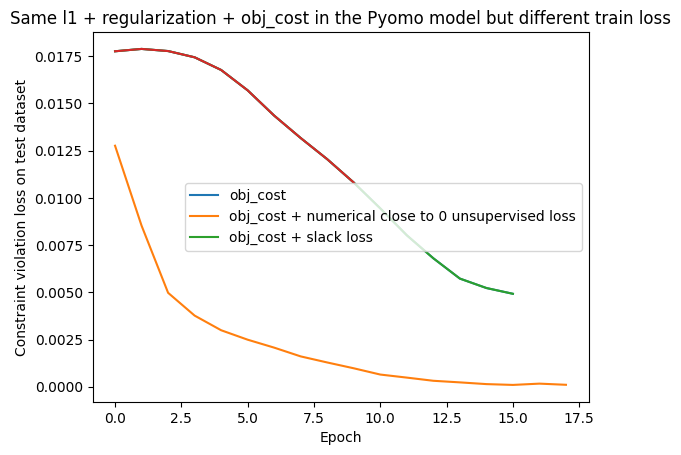

In [133]:
plt.plot(l2l1, label = "obj_cost")
plt.plot(l2l1_unsupervised, label = "obj_cost + numerical close to 0 unsupervised loss")
plt.plot(l2l1_slack, label = "obj_cost + slack loss")
plt.plot(l2l1_slack2)
plt.xlabel("Epoch")
plt.ylabel("Constraint violation loss on test dataset")
plt.title("Same l1 + regularization + obj_cost in the Pyomo model but different train loss")
plt.legend()

In [126]:
l2l1

array([0.0177623 , 0.01788689, 0.01777382, 0.01744312, 0.01677151,
       0.01569312, 0.0143548 , 0.01316803, 0.01204711, 0.01081001,
       0.00944309, 0.00801924, 0.00680162, 0.00572659, 0.00522707,
       0.00492084])

In [127]:
l2l1_slack

array([0.0177623 , 0.01788689, 0.01777382, 0.01744312, 0.01677151,
       0.01569312, 0.0143548 , 0.01316803, 0.01204711, 0.01081001,
       0.00944309, 0.00801924, 0.00680162, 0.00572659, 0.00522707,
       0.00492084])

In [21]:
def create_model(nominal_p):
    # Create a concrete model
    m = pyo.ConcreteModel()

    m.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    m.ipopt_zL_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    m.ipopt_zU_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)

    # Define variables
    m.x = pyo.Var(range(1), within=pyo.NonNegativeReals)
    m.p = pyo.Var(range(1), within=pyo.Reals)
    m.s = pyo.Var(range(1), within=pyo.Reals)
    
    m.obj_weight = pyo.Param(initialize=0, within=pyo.NonNegativeReals, mutable=True)
    m.p[0].fix(nominal_p[0])
    # m.s[0].fix(0)
    # Define equality constraints
    m.equ_constraints = pyo.ConstraintList()

    m.equ_constraints.add(m.x[0] + m.p[0] + m.s[0] == 0)
    
    # Define objective function: 
    def objective_rule(m):
        return m.s[0]**2 + m.x[0]**2
        
    m.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)
     
    return m

In [30]:
def create_model(nominal_p):
    # Create a concrete model
    m = pyo.ConcreteModel()

    m.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    m.ipopt_zL_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    m.ipopt_zU_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)

    # Define variables
    dimension = 1
    m.x = pyo.Var(range(dimension), within=pyo.NonNegativeReals)
    m.p = pyo.Var(range(dimension), within=pyo.Reals)
    m.s_pos = pyo.Var(range(dimension), within=pyo.NonNegativeReals)
    m.s_neg = pyo.Var(range(dimension), within=pyo.NonNegativeReals)

    m.obj_weight = pyo.Param(initialize=1, within=pyo.NonNegativeReals, mutable=True)

    m.p[0].fix(nominal_p[0])
    m.s_pos[0].fix(0)
    m.s_neg[0].fix(0)
    # Define equality constraints
    m.equ_constraints = pyo.ConstraintList()

    m.equ_constraints.add(m.x[0] + m.p[0] + m.s_pos[0] - m.s_neg[0]== 0)
    
    # Define objective function: 
    def objective_rule(m):
        return  m.obj_weight * m.x[0]**2 + m.s_pos[0] + m.s_neg[0] + 0.00001 * (m.s_pos[0]**2 + m.s_neg[0]**2) 
        
    m.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)
     
    return m

In [6]:
def create_model(nominal_p):
    # Create a concrete model
    m = pyo.ConcreteModel()

    m.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    m.ipopt_zL_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    m.ipopt_zU_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)

    # Define variables
    dimension = 1
    m.x = pyo.Var(range(dimension), within=pyo.NonNegativeReals)
    m.p = pyo.Var(range(dimension), within=pyo.Reals)
    m.s_pos = pyo.Var(range(dimension), within=pyo.NonNegativeReals)

    m.obj_weight = pyo.Param(initialize=1, within=pyo.NonNegativeReals, mutable=True)

    m.p[0].fix(nominal_p[0])
    m.s_pos[0].fix(0)

    # Define equality constraints
    m.equ_constraints = pyo.ConstraintList()

    m.equ_constraints.add(m.x[0] + m.p[0] - m.s_pos[0] == 0)
    
    # Define objective function: 
    def objective_rule(m):
        return m.s_pos[0] 
        
    m.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)
     
    return m

In [22]:
np.random.seed(0)
p = np.abs(np.random.rand(1))
print(p)
model = create_model(-p)
opt = pyo.SolverFactory('ipopt')
results = opt.solve(model, tee=True) 
print(results)
model.display()
print(model.obj())

[0.5488135]
Ipopt 3.14.17: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.17, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:        2
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        2

Total number of variables............................:        2
                     variables with only lower bounds:        1
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1


In [32]:
variables_name = [model.x]
parameters_name = [model.p]
slacks_name = [model.s_pos, model.s_neg]
known_parameters_name = None
free_parameters_name = None
Layer = PyomoOptLayer(model, variables_name, parameters_name, free_parameters_name, known_parameters_name, slacks_name)

In [8]:
variables_name = [model.x]
parameters_name = [model.p]
slacks_name = [model.s_pos]
known_parameters_name = None
free_parameters_name = None
Layer = PyomoOptLayer(model, variables_name, parameters_name, free_parameters_name, known_parameters_name, slacks_name)

In [23]:
variables_name = [model.x]
parameters_name = [model.p]
slacks_name = [model.s]
known_parameters_name = None
free_parameters_name = None
Layer = PyomoOptLayer(model, variables_name, parameters_name, free_parameters_name, known_parameters_name, slacks_name)

In [24]:
input = tuple([torch.tensor(p, requires_grad=True)])
primal_batch, slack_out, dual_out,  left, right = Layer(*input)
print("slack_out",slack_out)
print(dual_out)

tensor([[[-0.5000]]])
tensor([[[-0.5000]]])
slack_out tensor([[-0.5488]], grad_fn=<PyomoLayerFnFnBackward>)
tensor([[1.0976]], grad_fn=<PyomoLayerFnFnBackward>)


In [9]:
input = tuple([torch.tensor(p, requires_grad=True)])
primal_batch, slack_out, dual_out, left, right = Layer(*input)
print("slack_out",slack_out)
print(dual_out)

tensor([[[-2.0849e-17]]])
tensor([[[1.]]])
slack_out tensor([[0.5488]], grad_fn=<PyomoLayerFnFnBackward>)
tensor([[1.0000]], grad_fn=<PyomoLayerFnFnBackward>)


In [34]:
input = tuple([torch.tensor(p, requires_grad=True)])
primal_batch, slack_out, dual_out,  left, right = Layer(*input)
print("slack_out",slack_out)
print(dual_out)

slack_out tensor([[-8.7487e-09,  4.1702e-01]], grad_fn=<PyomoLayerFnFnBackward>)
tensor([[1.0000]], grad_fn=<PyomoLayerFnFnBackward>)


In [16]:
print(p)

[0.5488135]


In [10]:
print(left)

[[array([[ 8.34037122e-09,  0.00000000e+00, -1.00000000e+00],
       [ 0.00000000e+00,  4.00045037e+08,  1.00000000e+00],
       [-1.00000000e+00,  1.00000000e+00,  0.00000000e+00]])]]


In [11]:
print(right)

[[array([[0.],
       [0.],
       [1.]])]]


In [12]:
np.linalg.inv(left)

array([[[[ 2.49971855e-09,  2.49971855e-09, -1.00000000e+00],
         [ 2.49971855e-09,  2.49971855e-09,  2.08485807e-17],
         [-1.00000000e+00,  2.08485807e-17, -8.34037122e-09]]]])

In [ ]:
np.linalg.inv(left) 